## Part 1: Environment Setup & Core Similarity Functions

This section initializes the required libraries and defines the core mathematical functions used to compute the similarity between triclusters. The similarity framework evaluates both the **Structural Component** (geometric overlap based on Jaccard similarity) and the **Data Value Component** (profiling numerical, ordinal, and nominal features).

The functions included here cover:
* **Statistical Profiling:** Dynamic calculation of Interquartile Ranges (IQR), feature weights (normalized entropy), and ordinal rank mappings.
* **Distance Metrics:** Implementations of normalized Euclidean distances and Kronecker deltas for heterogeneous data.
* **Symmetric Similarities:** Natively vectorized Horizontal, Vertical, and Combined similarity evaluations.
* **Baseline & Virtual Pattern Wrappers:** Functions to compute baseline directional metrics (Hyper-box boundary) and Virtual Pattern approaches (Gower, Hybrid).

In [4]:
# ==============================================================================
# LIBRARIES AND DEPENDENCIES
# ==============================================================================
import inspect
import random
#import re
import time
import warnings
from collections import Counter
#from math import log
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
#import seaborn as sns
#from scipy.stats import iqr

# Custom module imports (Ensure these are available in the repository path)
#from TriHSPAM import TriHSPAM
from visualize_patterns import compute_representative_patterns

# Machine Learning imports
#from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
#from sklearn.preprocessing import StandardScaler
#from sklearn.pipeline import Pipeline
#from sklearn.metrics import (
#    classification_report, ConfusionMatrixDisplay, RocCurveDisplay, 
#    roc_auc_score, average_precision_score, f1_score, confusion_matrix, recall_score
#)
#from sklearn.linear_model import LogisticRegression
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.svm import SVC
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.exceptions import ConvergenceWarning
#from xgboost import XGBClassifier

# Suppress convergence and external module warnings for a cleaner output
#warnings.filterwarnings('ignore', category=ConvergenceWarning)
#warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')


# ==============================================================================
# DYNAMIC FEATURE STATISTICS
# ==============================================================================
def build_feature_stats(data_tensor, num_idx, symb_idx, ordinal_map=None, eps=1e-6):
    """
    Calculates Interquartile Range (IQR), Weights, and Ranks based on the actual 
    variance of the data_tensor, applying strict NaN filtering.
    """
    n_features = data_tensor.shape[0]
    iqr_dict = {}
    raw_weight = {}
    rank_dict = {}
    
    # 1. Numerical Features: IQR and Weights
    for f in num_idx:
        vals = data_tensor[f, :, :].ravel()
        numeric = []
        for v in vals:
            try:
                vf = float(v)
                if not np.isnan(vf):
                    numeric.append(vf)
            except (ValueError, TypeError):
                continue
                
        if len(numeric) == 0:
            iqr_val = 1.0
        else:
            arr = np.array(numeric, dtype=float)
            q75, q25 = np.percentile(arr, [75, 25])
            iqr_val = q75 - q25
            
            if iqr_val == 0:
                std = np.std(arr)
                iqr_val = std if std > 0 else eps
                
        iqr_dict[f] = float(iqr_val)
        raw_weight[f] = 1.0 / (iqr_dict[f] + eps)

    # 2. Symbolic Features: Normalized Entropy and Weights
    for f in symb_idx:
        vals = data_tensor[f, :, :].ravel()
        cats = [v for v in vals if (v is not None) and (v != '') and not (isinstance(v, (float, np.floating)) and np.isnan(v))]
        
        if len(cats) == 0:
            raw_weight[f] = 0.0
            continue
            
        counts = Counter(cats)
        L = len(counts)
        if L <= 1:
            H_norm = 0.0
        else:
            pk = np.array(list(counts.values()), dtype=float) / sum(counts.values())
            H = -np.sum(pk * np.log(pk))
            H_norm = H / (np.log(L) + eps)
            
        raw_weight[f] = float(1.0 - H_norm)

    # 3. Ordinal Features: Rank Mapping Dictionary
    if ordinal_map:
        for f, ordered_list in ordinal_map.items():
            L = len(ordered_list)
            if L <= 1:
                rank_dict[f] = {ordered_list[0]: 0.0} if L == 1 else {}
            else:
                rank_dict[f] = {c: (i / (L - 1)) for i, c in enumerate(ordered_list)}

    return iqr_dict, raw_weight, rank_dict


# ==============================================================================
# STRUCTURAL SIMILARITY & BASE DISTANCE METRICS
# ==============================================================================
def similarity_structural(tric_A, tric_B, alpha_I=1/3, alpha_J=1/3, alpha_K=1/3):
    """
    Computes the structural intersection between two triclusters using Jaccard Similarity.
    Sim_S(T_A, T_B) = α_I*Jaccard(I) + α_J*Jaccard(J) + α_K*Jaccard(K)
    """
    I_A, J_A, K_A = set(tric_A[0]), set(tric_A[1]), set(tric_A[2])
    I_B, J_B, K_B = set(tric_B[0]), set(tric_B[1]), set(tric_B[2])
    
    def jaccard(set1, set2):
        union_len = len(set1.union(set2))
        return len(set1.intersection(set2)) / union_len if union_len > 0 else 0.0
        
    sim_I = jaccard(I_A, I_B)
    sim_J = jaccard(J_A, J_B)
    sim_K = jaccard(K_A, K_B)
    
    return (alpha_I * sim_I) + (alpha_J * sim_J) + (alpha_K * sim_K)

def compute_distance_numerical(val_A, val_B, f_idx, min_dict, max_dict):
    """Min-Max normalization and squared Euclidean distance calculation."""
    min_val = min_dict.get(f_idx, 0.0)
    max_val = max_dict.get(f_idx, 1.0)
    
    amplitude = max_val - min_val if max_val != min_val else 1e-6 
        
    norm_A = (val_A - min_val) / amplitude
    norm_B = (val_B - min_val) / amplitude
    
    return (norm_A - norm_B) ** 2  

def compute_distance_ordinal(val_A, val_B, f_idx, rank_dict):
    """Ordinal distance based on normalized ranks."""
    r_map = rank_dict.get(f_idx, {})
    rank_A, rank_B = r_map.get(val_A, 0), r_map.get(val_B, 0)
    r_j = len(r_map)
    
    if r_j <= 1:
        return 0.0
        
    norm_diff = abs(rank_A - rank_B) / (r_j - 1)
    return norm_diff ** 2  

def compute_similarity_nominal(val_A, val_B):
    """Kronecker delta for nominal values (1 if strictly equal, 0 otherwise)."""
    return 1.0 if val_A == val_B else 0.0


# ==============================================================================
# SYMMETRIC SIMILARITY METRICS
# ==============================================================================
def calculate_horizontal_similarity(tric_A, tric_B, data_tensor, min_dict, max_dict, rank_dict, num_idx, ord_idx, nom_idx, lambda_param=0.5, alpha_weights=(1/3, 1/3, 1/3), aggregate_time=True):
    I_A, J_A, K_A = tric_A
    I_B, J_B, K_B = tric_B
    
    J_AB = sorted(list(set(J_A).intersection(set(J_B))))
    K_AB = sorted(list(set(K_A).intersection(set(K_B))))
    
    sim_s = similarity_structural(tric_A, tric_B, *alpha_weights) if lambda_param > 0.0 else 0.0
        
    if not J_AB or not K_AB:
        return (lambda_param * sim_s) if aggregate_time else {}

    j_num = [j for j in J_AB if j in num_idx]
    j_ord = [j for j in J_AB if j in ord_idx]
    j_nom = [j for j in J_AB if j in nom_idx]

    def get_profile_sim(idx_a, idx_b, k):
        s_num, s_ord, s_nom = 0.0, 0.0, 0.0
        
        # Numerical
        if j_num:
            d_sq, v_cnt = 0.0, 0
            for j in j_num:
                va, vb = data_tensor[j, idx_a, k], data_tensor[j, idx_b, k]
                if not (pd.isna(va) or pd.isna(vb)):
                    d_sq += compute_distance_numerical(va, vb, j, min_dict, max_dict)
                    v_cnt += 1
            if v_cnt > 0: s_num = 1.0 / (1.0 + np.sqrt(d_sq))
            
        # Ordinal
        if j_ord:
            d_sq, v_cnt = 0.0, 0
            for j in j_ord:
                va, vb = data_tensor[j, idx_a, k], data_tensor[j, idx_b, k]
                if not (pd.isna(va) or pd.isna(vb)):
                    d_sq += compute_distance_ordinal(va, vb, j, rank_dict)
                    v_cnt += 1
            if v_cnt > 0: s_ord = 1.0 / (1.0 + np.sqrt(d_sq))
            
        # Nominal
        if j_nom:
            m_cnt, v_cnt = 0, 0
            for j in j_nom:
                va, vb = data_tensor[j, idx_a, k], data_tensor[j, idx_b, k]
                if not (pd.isna(va) or pd.isna(vb)):
                    m_cnt += compute_similarity_nominal(va, vb)
                    v_cnt += 1
            if v_cnt > 0: s_nom = m_cnt / v_cnt
            
        wn, wo, wm = len(j_num)/len(J_AB), len(j_ord)/len(J_AB), len(j_nom)/len(J_AB)
        return (wn*s_num) + (wo*s_ord) + (wm*s_nom)

    sims_per_time = {}
    for k in K_AB:
        sim_ab = sum(max([get_profile_sim(a, b, k) for b in I_B]) for a in I_A) / len(I_A)
        sim_ba = sum(max([get_profile_sim(b, a, k) for a in I_A]) for b in I_B) / len(I_B)
        
        sim_h_k = 0.5 * (sim_ab + sim_ba)
        sims_per_time[k] = (lambda_param * sim_s) + ((1 - lambda_param) * sim_h_k)

    if aggregate_time:
        return np.mean(list(sims_per_time.values())) if sims_per_time else (lambda_param * sim_s)
    return sims_per_time


def calculate_vertical_similarity(tric_A, tric_B, data_tensor, min_dict, max_dict, rank_dict, num_idx, ord_idx, nom_idx, lambda_param=0.5, alpha_weights=(1/3, 1/3, 1/3), aggregate_time=True):
    I_A, J_A, K_A = tric_A
    I_B, J_B, K_B = tric_B
    
    J_AB = sorted(list(set(J_A).intersection(set(J_B))))
    K_AB = sorted(list(set(K_A).intersection(set(K_B))))
    
    sim_s = similarity_structural(tric_A, tric_B, *alpha_weights) if lambda_param > 0.0 else 0.0
        
    if not J_AB or not K_AB:
        return (lambda_param * sim_s) if aggregate_time else {}

    j_num = [j for j in J_AB if j in num_idx]
    j_ord = [j for j in J_AB if j in ord_idx]
    j_nom = [j for j in J_AB if j in nom_idx]
    
    sims_per_time = {}
    for k in K_AB:
        f_sims = 0.0
        
        # Numerical
        for j in j_num:
            diffs = [abs((data_tensor[j,a,k]-min_dict.get(j,0))/(max_dict.get(j,1)-min_dict.get(j,0) or 1e-6) - 
                         (data_tensor[j,b,k]-min_dict.get(j,0))/(max_dict.get(j,1)-min_dict.get(j,0) or 1e-6)) 
                     for a in I_A for b in I_B if not (pd.isna(data_tensor[j,a,k]) or pd.isna(data_tensor[j,b,k]))]
            f_sims += 1.0/(1.0+np.mean(diffs)) if diffs else 0.0
            
        # Ordinal
        for j in j_ord:
            r_map = rank_dict.get(j, {})
            diffs = [abs(r_map.get(data_tensor[j,a,k],0)-r_map.get(data_tensor[j,b,k],0))/(max(1, len(r_map)-1)) 
                     for a in I_A for b in I_B if not (pd.isna(data_tensor[j,a,k]) or pd.isna(data_tensor[j,b,k]))]
            f_sims += 1.0/(1.0+np.mean(diffs)) if diffs else 0.0
            
        # Nominal
        for j in j_nom:
            va = [data_tensor[j,a,k] for a in I_A if not pd.isna(data_tensor[j,a,k])]
            vb = [data_tensor[j,b,k] for b in I_B if not pd.isna(data_tensor[j,b,k])]
            if va and vb:
                ca, cb = Counter(va), Counter(vb)
                f_sims += sum((ca[c]/len(va)) * (cb[c]/len(vb)) for c in set(ca).union(set(cb)))
                
        sim_v_k = f_sims / len(J_AB) if len(J_AB) > 0 else 0.0
        sims_per_time[k] = (lambda_param * sim_s) + ((1 - lambda_param) * sim_v_k)

    if aggregate_time:
        return np.mean(list(sims_per_time.values())) if sims_per_time else (lambda_param * sim_s)
    return sims_per_time


def calculate_combined_similarity(tric_A=None, tric_B=None, data_tensor=None, 
                                  min_dict=None, max_dict=None, rank_dict=None, 
                                  num_idx=None, ord_idx=None, nom_idx=None, 
                                  lambda_param=0.5, alpha_weights=(1/3, 1/3, 1/3), 
                                  beta=0.5, aggregate_time=True,
                                  precomputed_H=None, precomputed_V=None): 
    
    if precomputed_H is not None and precomputed_V is not None:
        res_H = precomputed_H
        res_V = precomputed_V
    else:
        res_H = calculate_horizontal_similarity(tric_A, tric_B, data_tensor, min_dict, max_dict, rank_dict, num_idx, ord_idx, nom_idx, lambda_param, alpha_weights, aggregate_time)
        res_V = calculate_vertical_similarity(tric_A, tric_B, data_tensor, min_dict, max_dict, rank_dict, num_idx, ord_idx, nom_idx, lambda_param, alpha_weights, aggregate_time)
    
    if aggregate_time:
        return (beta * res_H) + ((1 - beta) * res_V)
    else:
        return {k: (beta * res_H.get(k, 0.0)) + ((1 - beta) * res_V.get(k, 0.0)) for k in res_H.keys()}


# ==============================================================================
# Hyper-Box AND VIRTUAL PATTERN (BASELINE) METRICS
# ==============================================================================
def similarity_baseline_boundary(triclusters, tric_id, patient_id, data_tensor, num_idx, symb_idx, rank_dict, aggregate_time=True):
    """
    Computes a Strict Hyper-box Boundary Baseline.
    Returns the compliance rate: the percentage of target patient values falling 
    within the strict min-max bounds of the reference cluster.
    """
    try:
        I, J, K = triclusters[tric_id]
    except IndexError:
        return np.nan

    rows_cluster = np.array(I, dtype=int)
    cols_feature = np.array(J, dtype=int)
    times_idx    = np.array(K, dtype=int)

    cluster_data = data_tensor[cols_feature, :, :][:, rows_cluster, :][:, :, times_idx]
    target_data  = data_tensor[cols_feature, patient_id, :][:, times_idx]
    
    local_num, local_ord, local_nom = [], [], []

    for i, f_glob in enumerate(J):
        if f_glob in num_idx:
            local_num.append(i)
        elif f_glob in symb_idx:
            if rank_dict is not None and f_glob in rank_dict:
                local_ord.append(i)
            else:
                local_nom.append(i)

    compliance_matrix = np.zeros((len(J), len(times_idx)))

    if local_num:
        c_vals = cluster_data[local_num, :, :].astype(float)
        t_vals = target_data[local_num, :].astype(float) 
        
        min_vals = np.min(c_vals, axis=1)
        max_vals = np.max(c_vals, axis=1)
        
        is_inside = (t_vals >= min_vals) & (t_vals <= max_vals)
        compliance_matrix[local_num, :] = is_inside.astype(float)

    if local_ord:
        n_members, n_times, n_ord = len(rows_cluster), len(times_idx), len(local_ord)
        c_ranks = np.zeros((n_ord, n_members, n_times))
        t_ranks = np.zeros((n_ord, n_times))
        
        for i, loc_idx in enumerate(local_ord):
            feat_glob = J[loc_idx]
            r_map = rank_dict.get(feat_glob, {})
            
            for t in range(n_times):
                t_ranks[i, t] = r_map.get(target_data[loc_idx, t], 0)
            for m in range(n_members):
                for t in range(n_times):
                    c_ranks[i, m, t] = r_map.get(cluster_data[loc_idx, m, t], 0)
        
        min_ranks = np.min(c_ranks, axis=1)
        max_ranks = np.max(c_ranks, axis=1)
        
        is_inside_ord = (t_ranks >= min_ranks) & (t_ranks <= max_ranks)
        compliance_matrix[local_ord, :] = is_inside_ord.astype(float)

    if local_nom:
        c_nom = cluster_data[local_nom, :, :]
        t_nom_exp = target_data[local_nom, np.newaxis, :]
        
        has_match = np.any(c_nom == t_nom_exp, axis=1)
        compliance_matrix[local_nom, :] = has_match.astype(float)

    compliance_per_time = np.mean(compliance_matrix, axis=0)
    
    if not aggregate_time:
         return {int(times_idx[t]): compliance_per_time[t] for t in range(len(times_idx))}
    return float(np.mean(compliance_per_time))


def similarity_virtual_pattern_gower(tric_A, tric_B, data_tensor, num_idx, symb_idx, iqr_dict, weight_raw, rank_dict=None, lambda_param=0.5, alpha_weights=(1/3, 1/3, 1/3), aggregate_time=True):
    """Compares two triclusters by calculating the Gower distance between their Virtual Patterns."""
    I_A, J_A, K_A = tric_A
    I_B, J_B, K_B = tric_B

    sim_s = similarity_structural(tric_A, tric_B, *alpha_weights)
    if lambda_param == 1.0: return sim_s

    J_AB = sorted(list(set(J_A).intersection(set(J_B))))
    K_AB = sorted(list(set(K_A).intersection(set(K_B))))

    if not J_AB or not K_AB: return (lambda_param * sim_s)

    sub_A = data_tensor[np.array(J_AB), :, :][:, np.array(I_A), :][:, :, np.array(K_AB)]
    sub_B = data_tensor[np.array(J_AB), :, :][:, np.array(I_B), :][:, :, np.array(K_AB)]

    local_num = [idx for idx, f in enumerate(J_AB) if f in num_idx]
    local_symb = [idx for idx, f in enumerate(J_AB) if f in symb_idx]

    pat_A = np.array(compute_representative_patterns(sub_A, local_symb, local_num, []), dtype=object)
    pat_B = np.array(compute_representative_patterns(sub_B, local_symb, local_num, []), dtype=object)

    sims_per_time = []
    for t_local in range(len(K_AB)):
        s_total, w_total = 0.0, 0.0

        for local_j, f_global in enumerate(J_AB):
            va, vb = pat_A[t_local, local_j], pat_B[t_local, local_j]
            w = float(weight_raw.get(f_global, 1.0))

            if f_global in num_idx:
                try:
                    num_a, num_b = float(va), float(vb)
                    iqrv = max(float(iqr_dict.get(f_global, 1.0)), 1e-6)
                    sim = max(0.0, 1.0 - abs(num_a - num_b) / iqrv)
                except (ValueError, TypeError): continue
            
            elif rank_dict is not None and f_global in rank_dict:
                if pd.isna(va) or pd.isna(vb): continue
                if va not in rank_dict[f_global] or vb not in rank_dict[f_global]:
                    sim = 1.0 if va == vb else 0.0
                else:
                    sim = 1.0 - abs(rank_dict[f_global][va] - rank_dict[f_global][vb])
            
            else:
                if pd.isna(va) or pd.isna(vb): continue
                sim = 1.0 if va == vb else 0.0

            s_total += w * sim
            w_total += w

        if w_total > 0:
            sims_per_time.append(s_total / w_total)

    if not sims_per_time: return (lambda_param * sim_s)

    sim_v_gower = float(np.mean(sims_per_time))
    return (lambda_param * sim_s) + ((1 - lambda_param) * sim_v_gower)


def similarity_virtual_pattern_hybrid(tric_A, tric_B, data_tensor, num_idx, symb_idx, iqr_dict, rank_dict=None, lambda_param=0.5, alpha_weights=(1/3, 1/3, 1/3), aggregate_time=True):
    """Compares two triclusters using the Hybrid metric applied to their Virtual Patterns."""
    I_A, J_A, K_A = tric_A
    I_B, J_B, K_B = tric_B

    sim_s = similarity_structural(tric_A, tric_B, *alpha_weights)
    if lambda_param == 1.0: return sim_s

    J_AB = sorted(list(set(J_A).intersection(set(J_B))))
    K_AB = sorted(list(set(K_A).intersection(set(K_B))))

    if not J_AB or not K_AB: return (lambda_param * sim_s)

    sub_A = data_tensor[np.array(J_AB), :, :][:, np.array(I_A), :][:, :, np.array(K_AB)]
    sub_B = data_tensor[np.array(J_AB), :, :][:, np.array(I_B), :][:, :, np.array(K_AB)]

    local_num = [idx for idx, f in enumerate(J_AB) if f in num_idx]
    local_symb = [idx for idx, f in enumerate(J_AB) if f in symb_idx]

    pat_A = np.array(compute_representative_patterns(sub_A, local_symb, local_num, []), dtype=object)
    pat_B = np.array(compute_representative_patterns(sub_B, local_symb, local_num, []), dtype=object)

    J_num = [j for j in J_AB if j in num_idx]
    J_ord = [j for j in J_AB if rank_dict is not None and j in rank_dict]
    J_nom = [j for j in J_AB if j not in J_num and j not in J_ord]

    α, β, γ = len(J_num)/len(J_AB), len(J_nom)/len(J_AB), len(J_ord)/len(J_AB)

    combined = []
    for t_local in range(len(K_AB)):
        sims_num, sims_nom, sims_ord = [], [], []

        for local_j, f_global in enumerate(J_AB):
            va, vb = pat_A[t_local, local_j], pat_B[t_local, local_j]

            if f_global in J_num:
                try:
                    num_a, num_b = float(va), float(vb)
                    iqrv = iqr_dict.get(f_global, 1.0) or 1e-6
                    sims_num.append(max(0.0, 1.0 - abs(num_a - num_b) / iqrv))
                except: continue
            elif f_global in J_nom:
                if pd.isna(va) or pd.isna(vb): continue
                sims_nom.append(1.0 if va == vb else 0.0)
            elif f_global in J_ord:
                if pd.isna(va) or pd.isna(vb): continue
                if va not in rank_dict[f_global] or vb not in rank_dict[f_global]:
                    sims_ord.append(1.0 if va == vb else 0.0)
                else:
                    sims_ord.append(1.0 - abs(rank_dict[f_global][va] - rank_dict[f_global][vb]))

        n = np.nanmean(sims_num) if sims_num else 0.0
        m = np.nanmean(sims_nom) if sims_nom else 0.0
        o = np.nanmean(sims_ord) if sims_ord else 0.0

        n = 0 if np.isnan(n) else n
        m = 0 if np.isnan(m) else m
        o = 0 if np.isnan(o) else o

        combined.append(α * n + β * m + γ * o)

    sim_v_hybrid = float(np.mean(combined)) if combined else 0.0
    return (lambda_param * sim_s) + ((1 - lambda_param) * sim_v_hybrid)


def wrapper_legacy_metric(tric_A, tric_B, data_tensor, legacy_metric_func, num_idx, symb_idx, rank_dict, iqr_dict=None, weight_raw=None, lambda_param=0.5, alpha_weights=(1/3, 1/3, 1/3), direction="A→B"):
    """
    Evaluates asymmetric instance-level metrics by wrapping target observations.
    Direction "A→B": Evaluates B's observations against A's template.
    Direction "B→A": Evaluates A's observations against B's template.
    """
    sim_s = similarity_structural(tric_A, tric_B, *alpha_weights)

    I_A, J_A, K_A = tric_A
    I_B, J_B, K_B = tric_B
    J_AB = sorted(list(set(J_A).intersection(set(J_B))))
    K_AB = sorted(list(set(K_A).intersection(set(K_B))))

    if not J_AB or not K_AB: return lambda_param * sim_s

    if direction == "A→B":
        tric_molde = (I_A, J_AB, K_AB) 
        obs_alvo = I_B                 
    else: 
        tric_molde = (I_B, J_AB, K_AB) 
        obs_alvo = I_A                 

    all_possible_args = {
        "triclusters":  [tric_molde],
        "tric_id":      0,
        "data_tensor":  data_tensor,
        "num_idx":      num_idx,
        "symb_idx":     symb_idx,
        "rank_dict":    rank_dict,
        "iqr_dict":     iqr_dict if iqr_dict else {},
        "weight_raw":   weight_raw if weight_raw else {f: 1.0 for f in range(data_tensor.shape[0])},
        "aggregate_time": True
    }

    sig = inspect.signature(legacy_metric_func)
    valid_params = sig.parameters.keys()

    instance_similarities = []
    for obs in obs_alvo:
        all_possible_args["patient_id"] = obs
        filtered_kwargs = {k: v for k, v in all_possible_args.items() if k in valid_params}
        sim = legacy_metric_func(**filtered_kwargs)
        instance_similarities.append(sim)

    sim_v_legacy = float(np.mean(instance_similarities))
    return (lambda_param * sim_s) + ((1 - lambda_param) * sim_v_legacy)

## Part 2: Sanity Checks & Individual Scenarios

This section systematically evaluates the proposed similarity metrics against 9 controlled scenarios (Sanity Checks). These tests isolate specific data behaviors to guarantee mathematical stability and correctness. 

The scenarios are divided into two main categories:
1. **Content Perturbations (Scenarios 1, 3, 4, 5):** The structural space remains fixed, while the internal data values are manipulated (e.g., identical match, noise injection, opposite values, and missing data/NaNs).
2. **Structural Perturbations (Scenarios 2, 6, 7, 8, 9):** The geometrical overlap is shifted across the observation ($I$), feature ($J$), or contextual ($K$) dimensions, testing the metrics' geometric penalization capabilities.

A unified `report_results` function is used to output the structural intersections, local statistics, and the final similarity scores for both the proposed symmetric metrics and the baseline approaches.

In [5]:
# ==============================================================================
# 1. GLOBAL EXPERIMENT DEFINITIONS
# ==============================================================================
# Feature indices mapping
num_idx = [0, 1]  # Features 0 and 1 are numerical (e.g., Blood Pressure, Age)
ord_idx = []      # No ordinal features in these specific controlled tests
nom_idx = [2]     # Feature 2 is nominal (e.g., Blood Type)

# Global normalization bounds for numerical features
min_dict = {0: 0.0, 1: 0.0}
max_dict = {0: 100.0, 1: 50.0}
rank_dict = {}

# Formula Weight Parameters 
lambda_param = 0.5  # 50% Structure, 50% Data Values
beta_param = 0.5    # 50% Horizontal, 50% Vertical
alpha_weights = (1/3, 1/3, 1/3) # Equal weights for I, J, K Jaccard similarities


# ==============================================================================
# 2. REPORTING FUNCTION
# ==============================================================================
def report_results(test_name, tric_A, tric_B, tensor):
    """
    Evaluates the tricluster pair and prints a formatted report of the structures, 
    local statistics, and final similarity scores across all metrics.
    """
    print(f"\n{'='*75}")
    print(f"🧪 SCENARIO: {test_name.upper()}")
    print(f"{'-'*75}")

    I_A, J_A, K_A = tric_A
    I_B, J_B, K_B = tric_B
    J_AB = sorted(list(set(J_A).intersection(set(J_B))))
    K_AB = sorted(list(set(K_A).intersection(set(K_B))))

    print("[ 1. TRICLUSTER STRUCTURES ]")
    print(f"  Reference (A) -> Observations: {I_A} | Features: {J_A} | Contexts: {K_A}")
    print(f"  Candidate (B) -> Observations: {I_B} | Features: {J_B} | Contexts: {K_B}")

    # Calculate local statistics for the current tensor
    iqr_dict, weight_dict, rank_dict_calc = build_feature_stats(tensor, num_idx, nom_idx)

    print("\n[ 2. COMPUTED LOCAL STATISTICS ]")
    print(f"  ➜ IQR Dict: {iqr_dict}")
    print(f"  ➜ Weight Dict: {weight_dict}")

    print("\n[ 3. FILTERING (COMPARISON WINDOW) ]")
    if not J_AB or not K_AB:
        print("  ⚠️ No structural overlap! Value-based metrics will return 0.0.")
    else:
        print(f"  ✂️ Shared Features evaluated : {J_AB}")
        print(f"  ✂️ Shared Contexts evaluated : {K_AB}")

        t_sample = K_AB[0]
        print(f"\n[ 4. DATA SAMPLE (Context t={t_sample}) ]")

        def safe_print(val):
            if isinstance(val, (float, int, np.floating)) and np.isnan(val):
                return "NaN"
            return val

        for j in J_AB:
            vals_A = [safe_print(tensor[j, a, t_sample]) for a in I_A]
            vals_B = [safe_print(tensor[j, b, t_sample]) for b in I_B]
            f_type = "Num" if j in num_idx else "Nom"
            print(f"  Feature {j} ({f_type}):\n    - Ref (A): {vals_A}\n    - Cand (B): {vals_B}")

    print("\n[ 5. FINAL SIMILARITY SCORES ]")

    # ── 1. Proposed Symmetric Metrics ─────────────────────────────────────────
    sim_h = calculate_horizontal_similarity(
        tric_A, tric_B, tensor, min_dict, max_dict,
        rank_dict_calc, num_idx, ord_idx, nom_idx,
        lambda_param, alpha_weights)
    
    sim_v = calculate_vertical_similarity(
        tric_A, tric_B, tensor, min_dict, max_dict,
        rank_dict_calc, num_idx, ord_idx, nom_idx,
        lambda_param, alpha_weights)
    
    sim_c = calculate_combined_similarity(
        tric_A, tric_B, tensor, min_dict, max_dict,
        rank_dict_calc, num_idx, ord_idx, nom_idx,
        lambda_param, alpha_weights, beta_param,
        aggregate_time=True,
        precomputed_H=sim_h, precomputed_V=sim_v)

    print("  --- Proposed Symmetric Metrics ---")
    print(f"  ➜ Horizontal (Sim_H) : {sim_h:.4f}")
    print(f"  ➜ Vertical   (Sim_V) : {sim_v:.4f}")
    print(f"  ➜ COMBINED   (Sim_C) : {sim_c:.4f}")

    # ── 2. Baseline Metrics (Virtual Pattern Approach) ────────────────────────
    sim_gower = similarity_virtual_pattern_gower(
        tric_A, tric_B, tensor, num_idx, nom_idx, iqr_dict, weight_dict, 
        rank_dict=rank_dict_calc, lambda_param=lambda_param, alpha_weights=alpha_weights
    )

    sim_hybr = similarity_virtual_pattern_hybrid(
        tric_A, tric_B, tensor, num_idx, nom_idx, iqr_dict, 
        rank_dict=rank_dict_calc, lambda_param=lambda_param, alpha_weights=alpha_weights
    )

    print("\n  --- Baselines (Virtual Pattern) ---")
    print(f"  ➜ Gower  (VP vs VP) : {sim_gower:.4f}")
    print(f"  ➜ Hybrid (VP vs VP) : {sim_hybr:.4f}")

    # ── 3. Baseline Metric (Hyper-box Boundary) ───────────────────────────────
    kwargs_base = dict(num_idx=num_idx, symb_idx=nom_idx, rank_dict=rank_dict_calc)
    
    base_ab = wrapper_legacy_metric(
        tric_A, tric_B, tensor, similarity_baseline_boundary,
        lambda_param=lambda_param, alpha_weights=alpha_weights,
        direction="A→B", **kwargs_base)

    base_ba = wrapper_legacy_metric(
        tric_A, tric_B, tensor, similarity_baseline_boundary,
        lambda_param=lambda_param, alpha_weights=alpha_weights,
        direction="B→A", **kwargs_base)

    base_mean = (base_ab + base_ba) / 2.0

    print("\n  --- Baseline (Hyper-box Boundary) ---")
    print(f"  {'Metric':<12} {'Sim(A→B)':>10} {'Sim(B→A)':>10} {'Mean':>10}")
    print(f"  {'-'*44}")
    print(f"  {'Hyper-box':<12} {base_ab:>10.4f} {base_ba:>10.4f} {base_mean:>10.4f}")

    print(f"{'='*75}\n")
    
    return {
        "Sim_H": sim_h, 
        "Sim_V": sim_v, 
        "Sim_C": sim_c,
        "Gower": sim_gower,
        "Hybrid": sim_hybr,
        "Hyper_Box_AB": base_ab,
        "Hyper_Box_BA": base_ba,
        "Hyper_Box_mean": base_mean
    }

# Test 1: Identical Triclusters 

In [6]:
# ==============================================================================
# SCENARIO 1: IDENTICAL TRICLUSTERS
# ==============================================================================
tensor_t1 = np.full((3, 6, 3), np.nan, dtype=object)

# Reference Tricluster (A)
tensor_t1[0, 0:3, :] = 50.0  # Feature 0
tensor_t1[1, 0:3, :] = 25.0  # Feature 1
tensor_t1[2, 0:3, :] = "A"   # Feature 2

# Candidate Tricluster (B) - Exact copy
tensor_t1[0, 3:6, :] = 50.0
tensor_t1[1, 3:6, :] = 25.0
tensor_t1[2, 3:6, :] = "A"

# Structural Coordinates: (Observations, Features, Contexts)
tric_A_t1 = ([0, 1, 2], [0, 1, 2], [0, 1, 2])
tric_B_t1 = ([0, 1, 2], [0, 1, 2], [0, 1, 2])

report_results("1. Identical Triclusters", tric_A_t1, tric_B_t1, tensor_t1)


🧪 SCENARIO: 1. IDENTICAL TRICLUSTERS
---------------------------------------------------------------------------
[ 1. TRICLUSTER STRUCTURES ]
  Reference (A) -> Observations: [0, 1, 2] | Features: [0, 1, 2] | Contexts: [0, 1, 2]
  Candidate (B) -> Observations: [0, 1, 2] | Features: [0, 1, 2] | Contexts: [0, 1, 2]

[ 2. COMPUTED LOCAL STATISTICS ]
  ➜ IQR Dict: {0: 1e-06, 1: 1e-06}
  ➜ Weight Dict: {0: 500000.0, 1: 500000.0, 2: 1.0}

[ 3. FILTERING (COMPARISON WINDOW) ]
  ✂️ Shared Features evaluated : [0, 1, 2]
  ✂️ Shared Contexts evaluated : [0, 1, 2]

[ 4. DATA SAMPLE (Context t=0) ]
  Feature 0 (Num):
    - Ref (A): [50.0, 50.0, 50.0]
    - Cand (B): [50.0, 50.0, 50.0]
  Feature 1 (Num):
    - Ref (A): [25.0, 25.0, 25.0]
    - Cand (B): [25.0, 25.0, 25.0]
  Feature 2 (Nom):
    - Ref (A): ['A', 'A', 'A']
    - Cand (B): ['A', 'A', 'A']

[ 5. FINAL SIMILARITY SCORES ]
  --- Proposed Symmetric Metrics ---
  ➜ Horizontal (Sim_H) : 1.0000
  ➜ Vertical   (Sim_V) : 1.0000
  ➜ COMBINED 

C:\Users\ruica\thesis\code\TriHSPAM-main\src\visualize_patterns.py:26: RuntimeWarning: Mean of empty slice
  vals[i] = round(np.nanmean(converted_column),2)
C:\Users\ruica\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


{'Sim_H': 1.0,
 'Sim_V': 1.0,
 'Sim_C': 1.0,
 'Gower': 1.0,
 'Hybrid': 1.0,
 'Hyper_Box_AB': 1.0,
 'Hyper_Box_BA': 1.0,
 'Hyper_Box_mean': 1.0}

# Test 2: Zero Structural Overlap

In [7]:
# ==============================================================================
# SCENARIO 2: COMPLETELY DIFFERENT (STRUCTURE & VALUES)
# ==============================================================================
tensor_t2 = np.full((6, 6, 6), np.nan, dtype=object)

# Reference Tricluster (A)
tensor_t2[0, 0:2, 0:2] = 100.0 
tensor_t2[1, 0:2, 0:2] = 50.0  
tensor_t2[2, 0:2, 0:2] = "A"   

# Candidate Tricluster (B)
tensor_t2[3, 4:6, 4:6] = 0.0   
tensor_t2[4, 4:6, 4:6] = 10.0  
tensor_t2[5, 4:6, 4:6] = "Z"   

tric_A_t2 = ([0, 1], [0, 1, 2], [0, 1])
tric_B_t2 = ([4, 5], [3, 4, 5], [4, 5])

report_results("2. Completely Different (No Overlap)", tric_A_t2, tric_B_t2, tensor_t2)


🧪 SCENARIO: 2. COMPLETELY DIFFERENT (NO OVERLAP)
---------------------------------------------------------------------------
[ 1. TRICLUSTER STRUCTURES ]
  Reference (A) -> Observations: [0, 1] | Features: [0, 1, 2] | Contexts: [0, 1]
  Candidate (B) -> Observations: [4, 5] | Features: [3, 4, 5] | Contexts: [4, 5]

[ 2. COMPUTED LOCAL STATISTICS ]
  ➜ IQR Dict: {0: 1e-06, 1: 1e-06}
  ➜ Weight Dict: {0: 500000.0, 1: 500000.0, 2: 1.0}

[ 3. FILTERING (COMPARISON WINDOW) ]
  ⚠️ No structural overlap! Value-based metrics will return 0.0.

[ 5. FINAL SIMILARITY SCORES ]
  --- Proposed Symmetric Metrics ---
  ➜ Horizontal (Sim_H) : 0.0000
  ➜ Vertical   (Sim_V) : 0.0000
  ➜ COMBINED   (Sim_C) : 0.0000

  --- Baselines (Virtual Pattern) ---
  ➜ Gower  (VP vs VP) : 0.0000
  ➜ Hybrid (VP vs VP) : 0.0000

  --- Baseline (Hyper-box Boundary) ---
  Metric         Sim(A→B)   Sim(B→A)       Mean
  --------------------------------------------
  Hyper-box        0.0000     0.0000     0.0000



{'Sim_H': 0.0,
 'Sim_V': 0.0,
 'Sim_C': 0.0,
 'Gower': 0.0,
 'Hybrid': 0.0,
 'Hyper_Box_AB': 0.0,
 'Hyper_Box_BA': 0.0,
 'Hyper_Box_mean': 0.0}

# Test 3: Small Noise

In [8]:
# ==============================================================================
# SCENARIO 3: SMALL NOISE (CLINICAL HETEROGENEITY)
# ==============================================================================
tensor_t3 = np.full((3, 6, 3), np.nan, dtype=object)

# Reference Tricluster (A)
tensor_t3[0, 0:3, :] = 50.0  
tensor_t3[1, 0:3, :] = 25.0  
tensor_t3[2, 0:3, :] = "A"   

# Candidate Tricluster (B) - Noise Injection
tensor_t3[0, 3, :] = [51.0, 49.0, 50.0]  
tensor_t3[0, 4, :] = [50.0, 52.0, 51.0]  
tensor_t3[0, 5, :] = [49.0, 51.0, 52.0]  

tensor_t3[1, 3, :] = [25.0, 26.0, 27.0]  
tensor_t3[1, 4, :] = [26.0, 27.0, 25.0]  
tensor_t3[1, 5, :] = [27.0, 25.0, 26.0]  

tensor_t3[2, 3, :] = ["A", "B", "A"]     
tensor_t3[2, 4, :] = ["B", "A", "B"]     
tensor_t3[2, 5, :] = ["A", "A", "B"]     

tric_A_t3 = ([0, 1, 2], [0, 1, 2], [0, 1, 2])
tric_B_t3 = ([3, 4, 5], [0, 1, 2], [0, 1, 2])

report_results("3. Small Noise (Heterogeneous clinical variation)", tric_A_t3, tric_B_t3, tensor_t3)


🧪 SCENARIO: 3. SMALL NOISE (HETEROGENEOUS CLINICAL VARIATION)
---------------------------------------------------------------------------
[ 1. TRICLUSTER STRUCTURES ]
  Reference (A) -> Observations: [0, 1, 2] | Features: [0, 1, 2] | Contexts: [0, 1, 2]
  Candidate (B) -> Observations: [3, 4, 5] | Features: [0, 1, 2] | Contexts: [0, 1, 2]

[ 2. COMPUTED LOCAL STATISTICS ]
  ➜ IQR Dict: {0: 0.75, 1: 1.0}
  ➜ Weight Dict: {0: 1.333331555557926, 1: 0.9999990000010001, 2: 0.23579659600384095}

[ 3. FILTERING (COMPARISON WINDOW) ]
  ✂️ Shared Features evaluated : [0, 1, 2]
  ✂️ Shared Contexts evaluated : [0, 1, 2]

[ 4. DATA SAMPLE (Context t=0) ]
  Feature 0 (Num):
    - Ref (A): [50.0, 50.0, 50.0]
    - Cand (B): [51.0, 50.0, 49.0]
  Feature 1 (Num):
    - Ref (A): [25.0, 25.0, 25.0]
    - Cand (B): [25.0, 26.0, 27.0]
  Feature 2 (Nom):
    - Ref (A): ['A', 'A', 'A']
    - Cand (B): ['A', 'B', 'A']

[ 5. FINAL SIMILARITY SCORES ]
  --- Proposed Symmetric Metrics ---
  ➜ Horizontal (Sim_

{'Sim_H': 0.7889935898756691,
 'Sim_V': 0.7543423186590422,
 'Sim_C': 0.7716679542673557,
 'Gower': 0.4596503446040046,
 'Hybrid': 0.5059259259259258,
 'Hyper_Box_AB': 0.5185185185185185,
 'Hyper_Box_BA': 0.8333333333333333,
 'Hyper_Box_mean': 0.6759259259259258}

# Test 4: Opposite Values

In [9]:
# ==============================================================================
# SCENARIO 4: IDENTICAL STRUCTURE, OPPOSITE VALUES
# ==============================================================================
tensor_t4 = np.full((3, 6, 3), np.nan, dtype=object)

# Reference Tricluster (A)
tensor_t4[0, 0:3, :] = 100.0 
tensor_t4[1, 0:3, :] = 50.0  
tensor_t4[2, 0:3, :] = "A"

# Candidate Tricluster (B)
tensor_t4[0, 3:6, :] = 0.0
tensor_t4[1, 3:6, :] = 0.0
tensor_t4[2, 3:6, :] = "B"

tric_A_t4 = ([0, 1, 2], [0, 1, 2], [0, 1, 2])
tric_B_t4 = ([3, 4, 5], [0, 1, 2], [0, 1, 2])

report_results("4. Opposite Values (Maximum distance within same structure)", tric_A_t4, tric_B_t4, tensor_t4)


🧪 SCENARIO: 4. OPPOSITE VALUES (MAXIMUM DISTANCE WITHIN SAME STRUCTURE)
---------------------------------------------------------------------------
[ 1. TRICLUSTER STRUCTURES ]
  Reference (A) -> Observations: [0, 1, 2] | Features: [0, 1, 2] | Contexts: [0, 1, 2]
  Candidate (B) -> Observations: [3, 4, 5] | Features: [0, 1, 2] | Contexts: [0, 1, 2]

[ 2. COMPUTED LOCAL STATISTICS ]
  ➜ IQR Dict: {0: 100.0, 1: 50.0}
  ➜ Weight Dict: {0: 0.0099999999, 1: 0.01999999960000001, 2: 1.4426929595412474e-06}

[ 3. FILTERING (COMPARISON WINDOW) ]
  ✂️ Shared Features evaluated : [0, 1, 2]
  ✂️ Shared Contexts evaluated : [0, 1, 2]

[ 4. DATA SAMPLE (Context t=0) ]
  Feature 0 (Num):
    - Ref (A): [100.0, 100.0, 100.0]
    - Cand (B): [0.0, 0.0, 0.0]
  Feature 1 (Num):
    - Ref (A): [50.0, 50.0, 50.0]
    - Cand (B): [0.0, 0.0, 0.0]
  Feature 2 (Nom):
    - Ref (A): ['A', 'A', 'A']
    - Cand (B): ['B', 'B', 'B']

[ 5. FINAL SIMILARITY SCORES ]
  --- Proposed Symmetric Metrics ---
  ➜ Horizont

{'Sim_H': 0.4714045207910316,
 'Sim_V': 0.5,
 'Sim_C': 0.4857022603955158,
 'Gower': 0.3333333333333333,
 'Hybrid': 0.3333333333333333,
 'Hyper_Box_AB': 0.3333333333333333,
 'Hyper_Box_BA': 0.3333333333333333,
 'Hyper_Box_mean': 0.3333333333333333}

# Test 5: Missing Data (NaNs)

In [10]:
# ==============================================================================
# SCENARIO 5: MISSING DATA (SCATTERED NaNs)
# ==============================================================================
tensor_t5 = np.full((3, 6, 3), np.nan, dtype=object)

# Reference Tricluster (A)
tensor_t5[0, 0:3, :] = 50.0  
tensor_t5[1, 0:3, :] = 25.0  
tensor_t5[2, 0:3, :] = "A"   

# Candidate Tricluster (B) - Base values
tensor_t5[0, 3:6, :] = 50.0
tensor_t5[1, 3:6, :] = 25.0
tensor_t5[2, 3:6, :] = "A"

# Injecting missing records
tensor_t5[0, 3, 1] = np.nan
tensor_t5[0, 3, 2] = np.nan

tensor_t5[1, 4, 0] = np.nan
tensor_t5[2, 4, 1] = np.nan  

tensor_t5[0, 5, 0] = np.nan  
tensor_t5[2, 5, 2] = np.nan

tric_A_t5 = ([0, 1, 2], [0, 1, 2], [0, 1, 2])
tric_B_t5 = ([3, 4, 5], [0, 1, 2], [0, 1, 2])

report_results("5. Missing Data (Scattered NaNs evaluation)", tric_A_t5, tric_B_t5, tensor_t5)


🧪 SCENARIO: 5. MISSING DATA (SCATTERED NANS EVALUATION)
---------------------------------------------------------------------------
[ 1. TRICLUSTER STRUCTURES ]
  Reference (A) -> Observations: [0, 1, 2] | Features: [0, 1, 2] | Contexts: [0, 1, 2]
  Candidate (B) -> Observations: [3, 4, 5] | Features: [0, 1, 2] | Contexts: [0, 1, 2]

[ 2. COMPUTED LOCAL STATISTICS ]
  ➜ IQR Dict: {0: 1e-06, 1: 1e-06}
  ➜ Weight Dict: {0: 500000.0, 1: 500000.0, 2: 1.0}

[ 3. FILTERING (COMPARISON WINDOW) ]
  ✂️ Shared Features evaluated : [0, 1, 2]
  ✂️ Shared Contexts evaluated : [0, 1, 2]

[ 4. DATA SAMPLE (Context t=0) ]
  Feature 0 (Num):
    - Ref (A): [50.0, 50.0, 50.0]
    - Cand (B): [50.0, 50.0, 'NaN']
  Feature 1 (Num):
    - Ref (A): [25.0, 25.0, 25.0]
    - Cand (B): [25.0, 'NaN', 25.0]
  Feature 2 (Nom):
    - Ref (A): ['A', 'A', 'A']
    - Cand (B): ['A', 'A', 'A']

[ 5. FINAL SIMILARITY SCORES ]
  --- Proposed Symmetric Metrics ---
  ➜ Horizontal (Sim_H) : 0.8148
  ➜ Vertical   (Sim_V) :

{'Sim_H': 0.8148148148148149,
 'Sim_V': 0.8333333333333334,
 'Sim_C': 0.8240740740740742,
 'Gower': 0.8333333333333333,
 'Hybrid': 0.8333333333333333,
 'Hyper_Box_AB': 0.7222222222222221,
 'Hyper_Box_BA': 0.611111111111111,
 'Hyper_Box_mean': 0.6666666666666665}

# Test 6: Different Observations

In [11]:
# ==============================================================================
# SCENARIO 6: DIFFERENT OBSERVATIONS
# ==============================================================================
tensor_t6 = np.full((3, 6, 3), np.nan, dtype=object)

# Reference Tricluster (A)
tensor_t6[0, 0:2, 0:2] = 50.0
tensor_t6[1, 0:2, 0:2] = 25.0
tensor_t6[2, 0:2, 0:2] = "A"

# Candidate Tricluster (B)
tensor_t6[0, 2:4, 0:2] = 50.0
tensor_t6[1, 2:4, 0:2] = 25.0
tensor_t6[2, 2:4, 0:2] = "A"

tric_A_t6 = ([0, 1], [0, 1, 2], [0, 1])
tric_B_t6 = ([2, 3], [0, 1, 2], [0, 1])

report_results("6. Different Observations (Disjoint I)", tric_A_t6, tric_B_t6, tensor_t6)


🧪 SCENARIO: 6. DIFFERENT OBSERVATIONS (DISJOINT I)
---------------------------------------------------------------------------
[ 1. TRICLUSTER STRUCTURES ]
  Reference (A) -> Observations: [0, 1] | Features: [0, 1, 2] | Contexts: [0, 1]
  Candidate (B) -> Observations: [2, 3] | Features: [0, 1, 2] | Contexts: [0, 1]

[ 2. COMPUTED LOCAL STATISTICS ]
  ➜ IQR Dict: {0: 1e-06, 1: 1e-06}
  ➜ Weight Dict: {0: 500000.0, 1: 500000.0, 2: 1.0}

[ 3. FILTERING (COMPARISON WINDOW) ]
  ✂️ Shared Features evaluated : [0, 1, 2]
  ✂️ Shared Contexts evaluated : [0, 1]

[ 4. DATA SAMPLE (Context t=0) ]
  Feature 0 (Num):
    - Ref (A): [50.0, 50.0]
    - Cand (B): [50.0, 50.0]
  Feature 1 (Num):
    - Ref (A): [25.0, 25.0]
    - Cand (B): [25.0, 25.0]
  Feature 2 (Nom):
    - Ref (A): ['A', 'A']
    - Cand (B): ['A', 'A']

[ 5. FINAL SIMILARITY SCORES ]
  --- Proposed Symmetric Metrics ---
  ➜ Horizontal (Sim_H) : 0.8333
  ➜ Vertical   (Sim_V) : 0.8333
  ➜ COMBINED   (Sim_C) : 0.8333

  --- Baselines

{'Sim_H': 0.8333333333333333,
 'Sim_V': 0.8333333333333333,
 'Sim_C': 0.8333333333333333,
 'Gower': 0.8333333333333333,
 'Hybrid': 0.8333333333333333,
 'Hyper_Box_AB': 0.8333333333333333,
 'Hyper_Box_BA': 0.8333333333333333,
 'Hyper_Box_mean': 0.8333333333333333}

# Test 7: Different Contexts/Time

In [12]:
# ==============================================================================
# SCENARIO 7: DIFFERENT CONTEXTS / TIMES
# ==============================================================================
tensor_t7 = np.full((3, 6, 6), np.nan, dtype=object)

# Reference Tricluster (A)
tensor_t7[0, 0:2, 0:2] = 50.0
tensor_t7[1, 0:2, 0:2] = 25.0
tensor_t7[2, 0:2, 0:2] = "A"

# Candidate Tricluster (B)
tensor_t7[0, 0:2, 2:4] = 50.0
tensor_t7[1, 0:2, 2:4] = 25.0
tensor_t7[2, 0:2, 2:4] = "A"

tric_A_t7 = ([0, 1], [0, 1, 2], [0, 1])
tric_B_t7 = ([0, 1], [0, 1, 2], [2, 3])

report_results("7. Different Contexts (Disjoint K)", tric_A_t7, tric_B_t7, tensor_t7)


🧪 SCENARIO: 7. DIFFERENT CONTEXTS (DISJOINT K)
---------------------------------------------------------------------------
[ 1. TRICLUSTER STRUCTURES ]
  Reference (A) -> Observations: [0, 1] | Features: [0, 1, 2] | Contexts: [0, 1]
  Candidate (B) -> Observations: [0, 1] | Features: [0, 1, 2] | Contexts: [2, 3]

[ 2. COMPUTED LOCAL STATISTICS ]
  ➜ IQR Dict: {0: 1e-06, 1: 1e-06}
  ➜ Weight Dict: {0: 500000.0, 1: 500000.0, 2: 1.0}

[ 3. FILTERING (COMPARISON WINDOW) ]
  ⚠️ No structural overlap! Value-based metrics will return 0.0.

[ 5. FINAL SIMILARITY SCORES ]
  --- Proposed Symmetric Metrics ---
  ➜ Horizontal (Sim_H) : 0.3333
  ➜ Vertical   (Sim_V) : 0.3333
  ➜ COMBINED   (Sim_C) : 0.3333

  --- Baselines (Virtual Pattern) ---
  ➜ Gower  (VP vs VP) : 0.3333
  ➜ Hybrid (VP vs VP) : 0.3333

  --- Baseline (Hyper-box Boundary) ---
  Metric         Sim(A→B)   Sim(B→A)       Mean
  --------------------------------------------
  Hyper-box        0.3333     0.3333     0.3333



{'Sim_H': 0.3333333333333333,
 'Sim_V': 0.3333333333333333,
 'Sim_C': 0.3333333333333333,
 'Gower': 0.3333333333333333,
 'Hybrid': 0.3333333333333333,
 'Hyper_Box_AB': 0.3333333333333333,
 'Hyper_Box_BA': 0.3333333333333333,
 'Hyper_Box_mean': 0.3333333333333333}

# Test 8: Subset Structure

In [13]:
# ==============================================================================
# SCENARIO 8: SUBSET STRUCTURE
# ==============================================================================
tensor_t8 = np.full((3, 6, 3), np.nan, dtype=object)

# Global support data
tensor_t8[0, 0:4, 0:3] = 50.0
tensor_t8[1, 0:4, 0:3] = 25.0
tensor_t8[2, 0:4, 0:3] = "A"

tric_A_t8 = ([0, 1, 2, 3], [0, 1, 2], [0, 1, 2])
tric_B_t8 = ([0, 1], [0, 1], [0, 1]) # Candidate strictly contained within Reference

report_results("8. Subset Structure (B is contained in A)", tric_A_t8, tric_B_t8, tensor_t8)


🧪 SCENARIO: 8. SUBSET STRUCTURE (B IS CONTAINED IN A)
---------------------------------------------------------------------------
[ 1. TRICLUSTER STRUCTURES ]
  Reference (A) -> Observations: [0, 1, 2, 3] | Features: [0, 1, 2] | Contexts: [0, 1, 2]
  Candidate (B) -> Observations: [0, 1] | Features: [0, 1] | Contexts: [0, 1]

[ 2. COMPUTED LOCAL STATISTICS ]
  ➜ IQR Dict: {0: 1e-06, 1: 1e-06}
  ➜ Weight Dict: {0: 500000.0, 1: 500000.0, 2: 1.0}

[ 3. FILTERING (COMPARISON WINDOW) ]
  ✂️ Shared Features evaluated : [0, 1]
  ✂️ Shared Contexts evaluated : [0, 1]

[ 4. DATA SAMPLE (Context t=0) ]
  Feature 0 (Num):
    - Ref (A): [50.0, 50.0, 50.0, 50.0]
    - Cand (B): [50.0, 50.0]
  Feature 1 (Num):
    - Ref (A): [25.0, 25.0, 25.0, 25.0]
    - Cand (B): [25.0, 25.0]

[ 5. FINAL SIMILARITY SCORES ]
  --- Proposed Symmetric Metrics ---
  ➜ Horizontal (Sim_H) : 0.8056
  ➜ Vertical   (Sim_V) : 0.8056
  ➜ COMBINED   (Sim_C) : 0.8056

  --- Baselines (Virtual Pattern) ---
  ➜ Gower  (VP vs V

{'Sim_H': 0.8055555555555556,
 'Sim_V': 0.8055555555555556,
 'Sim_C': 0.8055555555555556,
 'Gower': 0.8055555555555556,
 'Hybrid': 0.8055555555555556,
 'Hyper_Box_AB': 0.8055555555555556,
 'Hyper_Box_BA': 0.8055555555555556,
 'Hyper_Box_mean': 0.8055555555555556}

# Test 9: Shifted Structure

In [14]:
# ==============================================================================
# SCENARIO 9: SHIFTED STRUCTURE WITH PARTIAL OVERLAP
# ==============================================================================
tensor_t9 = np.full((4, 6, 6), np.nan, dtype=object)

tensor_t9[0, 0:3, 0:3] = 80.0
tensor_t9[1, 0:3, 0:4] = 25.0  # Shared feature
tensor_t9[2, 0:3, 0:4] = "A"   # Shared feature
tensor_t9[3, 0:3, 1:4] = 99.0

tric_A_t9 = ([0, 1, 2], [0, 1, 2], [0, 1, 2])
tric_B_t9 = ([0, 1, 2], [1, 2, 3], [1, 2, 3]) 

report_results("9. Shifted Structure (Partial geometric overlap)", tric_A_t9, tric_B_t9, tensor_t9)


🧪 SCENARIO: 9. SHIFTED STRUCTURE (PARTIAL GEOMETRIC OVERLAP)
---------------------------------------------------------------------------
[ 1. TRICLUSTER STRUCTURES ]
  Reference (A) -> Observations: [0, 1, 2] | Features: [0, 1, 2] | Contexts: [0, 1, 2]
  Candidate (B) -> Observations: [0, 1, 2] | Features: [1, 2, 3] | Contexts: [1, 2, 3]

[ 2. COMPUTED LOCAL STATISTICS ]
  ➜ IQR Dict: {0: 1e-06, 1: 1e-06}
  ➜ Weight Dict: {0: 500000.0, 1: 500000.0, 2: 1.0}

[ 3. FILTERING (COMPARISON WINDOW) ]
  ✂️ Shared Features evaluated : [1, 2]
  ✂️ Shared Contexts evaluated : [1, 2]

[ 4. DATA SAMPLE (Context t=1) ]
  Feature 1 (Num):
    - Ref (A): [25.0, 25.0, 25.0]
    - Cand (B): [25.0, 25.0, 25.0]
  Feature 2 (Nom):
    - Ref (A): ['A', 'A', 'A']
    - Cand (B): ['A', 'A', 'A']

[ 5. FINAL SIMILARITY SCORES ]
  --- Proposed Symmetric Metrics ---
  ➜ Horizontal (Sim_H) : 0.8333
  ➜ Vertical   (Sim_V) : 0.8333
  ➜ COMBINED   (Sim_C) : 0.8333

  --- Baselines (Virtual Pattern) ---
  ➜ Gower  (

{'Sim_H': 0.8333333333333333,
 'Sim_V': 0.8333333333333333,
 'Sim_C': 0.8333333333333333,
 'Gower': 0.8333333333333333,
 'Hybrid': 0.8333333333333333,
 'Hyper_Box_AB': 0.8333333333333333,
 'Hyper_Box_BA': 0.8333333333333333,
 'Hyper_Box_mean': 0.8333333333333333}

## Part 3: Visual Representations (Matrix Generation)

This section contains the rendering engine used to generate the 2D representations of the 3D triclusters evaluated in the Sanity Checks. It leverages `matplotlib` to draw the matrices across the temporal dimension ($K$).

The script is configured to:
* Use a color-coded schema to differentiate between numerical, nominal, and missing (NaN) data.
* Render the matrices with enlarged typography tailored for readability in scientific papers.
* Export the generated figures with a transparent background in both high-resolution PNG and vector-based PDF formats, ready for LaTeX or presentation integration.

In [15]:
# ==============================================================================
# 1. VISUALIZATION ENGINE SETUP & CONFIGURATIONS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

OUT_DIR = Path("./output_tricluster_tables_compact")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Soft color palette for paper readability
COL_A      = "#3498DB"
COL_B      = "#E74C3C"
COL_NUM    = "#F4F6F6"  # Light gray
COL_NOM    = "#E8F8F5"  # Light green
COL_NAN    = "#FDEDEC"  # Light red
COL_BORDER = "#BDC3C7"
TXT_NAN    = "#E74C3C"
TXT_NOM    = "#117A65"
TXT_NUM    = "#2C3E50"
TXT_DARK   = "#2C3E50"
COL_HIGHLIGHT_BOX = "#F1C40F" 

# Typography scaling tailored for scientific publications
FS_CELL    = 16  # Matrix cell values
FS_HEADER  = 18  # Dimensional labels (J_j, I_i, K_k)
FS_TITLE   = 18  # Optional title font size

def _fmt(v):
    """Formats values for clean display within the matrix cells."""
    if v is None: return "NaN"
    if isinstance(v, float) and np.isnan(v): return "NaN"
    if isinstance(v, (float, np.floating)):
        return f"{v:.1f}" if v != int(v) else f"{int(v)}"
    return str(v)

def _isnan(v):
    """Robust NaN checking across data types."""
    if v is None: return True
    try: return np.isnan(float(v))
    except: return False

def draw_compact_tricluster_by_time(ax, tensor, tric, color, num_idx, nom_idx):
    """Draws a 3D tricluster mapped across the 2D plane separated by time contexts."""
    I, J, K = tric
    n_obs  = len(I)
    n_feat = len(J)
    
    # Scale adjustments to accommodate larger typography
    CELL_S = 1.3  
    GAP = 0.6     

    for t_idx, k in enumerate(K):
        x_offset = t_idx * (n_feat * CELL_S + GAP)

        # Context (Time) Label (K_k) - Positioned below the matrix
        ax.text(x_offset + (n_feat * CELL_S)/2, -0.3,
                f"$K_{{{k}}}$", ha='center', va='top', 
                fontweight='bold', fontsize=FS_HEADER + 2, color=TXT_DARK)

        # Highlight Bounding Box for the current context
        outer_rect = mpatches.Rectangle((x_offset, 0), n_feat * CELL_S, n_obs * CELL_S,
                                        linewidth=2.0, edgecolor=COL_HIGHLIGHT_BOX, facecolor='none', zorder=10)
        ax.add_patch(outer_rect)

        for f_idx, j in enumerate(J):
            cx = x_offset + f_idx * CELL_S

            # Feature Label (J_j) - Positioned above the matrix
            ax.text(cx + CELL_S/2, n_obs * CELL_S + 0.2,
                    f"$J_{{{j}}}$", ha='center', va='bottom', 
                    fontsize=FS_HEADER, color=TXT_DARK)

            for o_idx, i in enumerate(I):
                cy = (n_obs - 1 - o_idx) * CELL_S

                # Observation Label (I_i) - Positioned on the left boundary
                if t_idx == 0 and f_idx == 0:
                    ax.text(x_offset - 0.4, cy + CELL_S/2,
                            f"$I_{{{i}}}$", ha='right', va='center', 
                            fontsize=FS_HEADER, color=TXT_DARK)

                v  = tensor[j, i, k]
                na = _isnan(v)
                nom = j in nom_idx

                fc, tc = (COL_NAN, TXT_NAN) if na else \
                         (COL_NOM, TXT_NOM) if nom else \
                         (COL_NUM, TXT_NUM)

                # Draw individual cell
                rect = mpatches.Rectangle((cx, cy), CELL_S, CELL_S,
                                          linewidth=0.8, edgecolor=COL_BORDER, facecolor=fc)
                ax.add_patch(rect)

                # Render cell value
                ax.text(cx + CELL_S/2, cy + CELL_S/2, _fmt(v),
                        ha='center', va='center', fontsize=FS_CELL, color=tc,
                        fontweight="bold" if na else "normal")
                
def render_compact(test_ids, which, filename):
    """Sets up the Matplotlib canvas and triggers the rendering of a specific tricluster."""
    tensor, tric_A, tric_B = ALL_TENSORS[test_ids[0]]
    tric    = tric_A if which == "A" else tric_B
    meta    = TEST_META[test_ids[0]]
    num_idx = meta["num"]
    nom_idx = meta["nom"]
    I, J, K = tric

    # Titles are disabled by default for external image composition
    show_title = False
    
    test_nums  = ", ".join(str(t) for t in test_ids)
    test_names = " / ".join(TEST_META[t]["name"] for t in test_ids)
    title_main = f"{test_nums}: {test_names}"
    
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.set_aspect('equal')
    ax.axis('off')

    draw_compact_tricluster_by_time(ax, tensor, tric, TXT_DARK, num_idx, nom_idx)

    # Calculate exact spatial boundaries based on structural sizes
    CELL_S = 1.3
    GAP = 0.6
    n_obs = len(I)
    total_width = len(K) * (len(J) * CELL_S) + (len(K) - 1) * GAP
    center_x = total_width / 2.0
    
    # Adjust crop windows to prevent typography clipping
    if show_title:
        ax.text(center_x, n_obs * CELL_S + 1.2, title_main, ha="center", va="bottom", 
                fontsize=FS_TITLE, fontweight="bold", color=TXT_DARK)
        ax.set_ylim(-1.5, n_obs * CELL_S + 1.8)
    else:
        ax.set_ylim(-1.5, n_obs * CELL_S + 1.2)

    ax.set_xlim(-1.8, total_width + 0.3)
    
    path = OUT_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)


# =====================================================================
# 2. SCENARIO DATA MAPPING
# =====================================================================
ALL_TENSORS = {
    1: (tensor_t1, tric_A_t1, tric_B_t1),
    2: (tensor_t2, tric_A_t2, tric_B_t2),
    3: (tensor_t3, tric_A_t3, tric_B_t3),
    4: (tensor_t4, tric_A_t4, tric_B_t4),
    5: (tensor_t5, tric_A_t5, tric_B_t5),
    6: (tensor_t6, tric_A_t6, tric_B_t6),
    7: (tensor_t7, tric_A_t7, tric_B_t7),
    8: (tensor_t8, tric_A_t8, tric_B_t8),
    9: (tensor_t9, tric_A_t9, tric_B_t9)
}

TEST_META = {
    1: {"name": "Identical Triclusters",        "num": [0,1],     "nom": [2]},
    2: {"name": "Completely Different",         "num": [0,1,3,4], "nom": [2,5]},
    3: {"name": "Small Noise",                  "num": [0,1],     "nom": [2]},
    4: {"name": "Opposite Values",              "num": [0,1],     "nom": [2]},
    5: {"name": "Missing Data",                 "num": [0,1],     "nom": [2]},
    6: {"name": "Different Patients",           "num": [0,1],     "nom": [2]},
    7: {"name": "Different Contexts",           "num": [0,1],     "nom": [2]},
    8: {"name": "Subset Structure",             "num": [0,1],     "nom": [2]},
    9: {"name": "Partial Structural Overlap",   "num": [0,1,3],   "nom": [2]}
}


# =====================================================================
# 3. VECTOR AND RASTER EXPORT PIPELINE
# =====================================================================
# Generate Reference Triclusters (A)
ref_exports = [
    ([1, 3, 4, 5], "tric_A_shared_T1_T3_T4_T5"),
    ([6, 7],       "tric_A_shared_T6_T7"),
    ([2],          "tric_A_T2"),
    ([8],          "tric_A_T8"),
    ([9],          "tric_A_T9")
]

for test_ids, file_prefix in ref_exports:
    render_compact(test_ids, "A", f"{file_prefix}.png")
    render_compact(test_ids, "A", f"{file_prefix}.pdf")

# Generate Candidate Triclusters (B)
for t in range(1, 10):
    render_compact([t], "B", f"tric_B_T{t}.png")
    render_compact([t], "B", f"tric_B_T{t}.pdf")
    
print("Compact visualizations generated successfully in PNG and PDF formats!")

Compact visualizations generated successfully in PNG and PDF formats!


## Part 4: Noise Sensitivity Test

This experiment evaluates the robustness of the similarity metrics against varying levels of data corruption. 

**Experimental Setup:**
1. **Reference Tricluster (A):** A clean, homogeneous sub-tensor.
2. **Candidate Tricluster (B):** A structurally identical sub-tensor (same features and contexts, distinct observations) subjected to a progressive noise injection function.
3. **Perturbation:** Heterogeneous noise is randomly applied to the Candidate's cells, ranging from 0% to 100%. Numerical features receive random continuous fluctuations, while nominal features are assigned completely distinct categories.

The objective is to demonstrate how the symmetric metrics penalize data divergence while keeping the structural similarity ($\lambda = 0.5$) constant. The results are summarized in a tabular format and visualized through a comparative line chart.

--- Starting Noise Sensitivity Stress Test ---


C:\Users\ruica\thesis\code\TriHSPAM-main\src\visualize_patterns.py:26: RuntimeWarning: Mean of empty slice
  vals[i] = round(np.nanmean(converted_column),2)
C:\Users\ruica\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Noise level 0% completed.
Noise level 30% completed.
Noise level 40% completed.
Noise level 50% completed.
Noise level 60% completed.
Noise level 70% completed.
Noise level 80% completed.
Noise level 90% completed.
Noise level 100% completed.


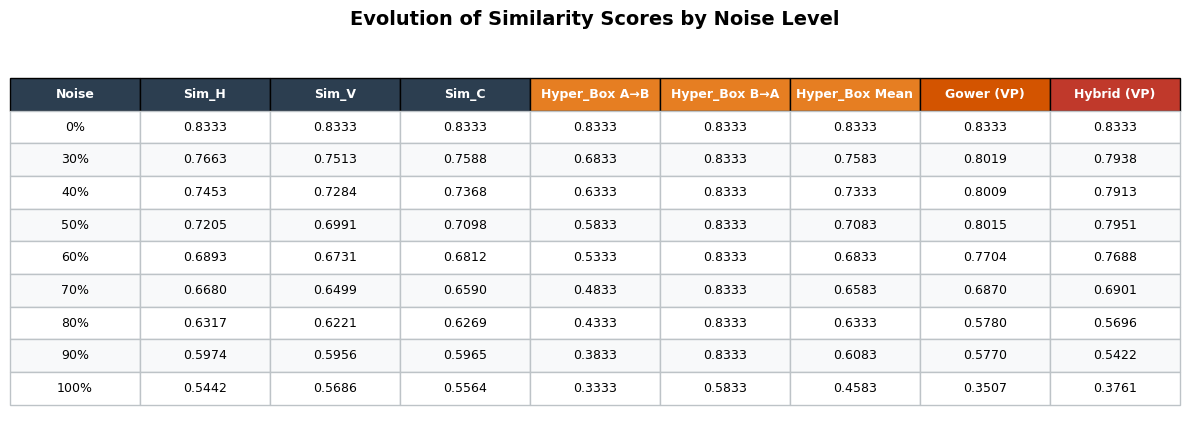

Chart successfully exported to:
 - C:\Users\ruica\thesis\code\TriHSPAM-main\src\noise_sensitivity_test\noise_sensitivity_test.png
 - C:\Users\ruica\thesis\code\TriHSPAM-main\src\noise_sensitivity_test\noise_sensitivity_test.pdf


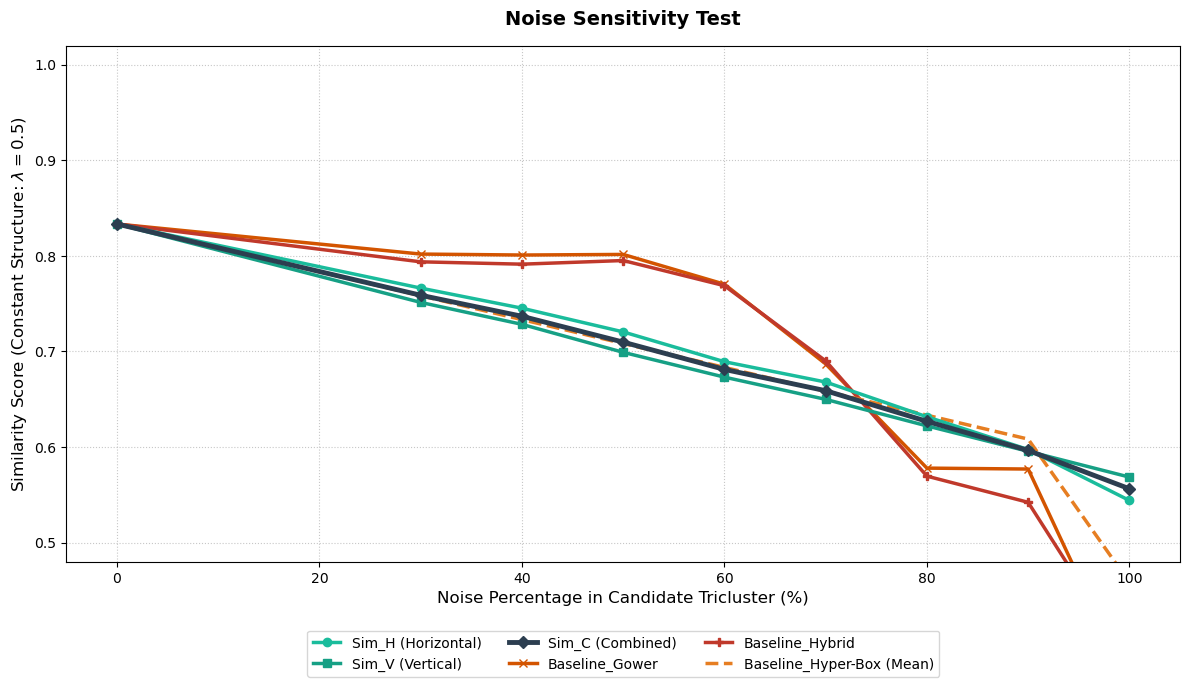

In [29]:
# ==============================================================================
# 1. BASE CONFIGURATION & TENSOR INITIALIZATION
# ==============================================================================
n_obs_group = 50   
n_feat = 20
n_time = 10

feat_num = list(range(10))
feat_nom = list(range(10, 20))
all_feat = feat_num + feat_nom

# Create the Global Tensor (100 total observations)
# 0-49: Reference Group (Clean) | 50-99: Candidate Group (Noisy)
tensor_data = np.full((n_feat, 100, n_time), np.nan, dtype=object)

# Initialize both groups with identical baseline values
for j in all_feat:
    if j in feat_num:
        tensor_data[j, :, :] = 50.0  
    else:
        tensor_data[j, :, :] = 'A'   

indices_A = list(range(0, 50))
indices_B = list(range(50, 100))
tempos = list(range(n_time))

tric_A = (indices_A, all_feat, tempos)
tric_B = (indices_B, all_feat, tempos)

min_dict = {j: 0.0 for j in feat_num}
max_dict = {j: 100.0 for j in feat_num}
rank_dict = {} 


# ==============================================================================
# 2. NOISE INJECTION FUNCTION
# ==============================================================================
def apply_noise_to_group_b(tensor, noise_pct, indices_b, feat_num, feat_nom, times):
    """
    Injects heterogeneous noise into a specified percentage of cells 
    within the candidate tricluster boundary.
    """
    new_tensor = tensor.copy()
    
    cells_b = [(j, i, k) for j in (feat_num + feat_nom) for i in indices_b for k in times]
    num_to_noise = int(len(cells_b) * (noise_pct / 100.0))
    target_cells = random.sample(cells_b, num_to_noise)
    
    for j, i, k in target_cells:
        if j in feat_num:
            # Continuous noise: +/- 12.5 (25% of baseline 50.0)
            new_tensor[j, i, k] = 50.0 + random.uniform(-12.5, 12.5)
        else:
            # Categorical noise: assignment to distinct categories
            new_tensor[j, i, k] = random.choice(['B', 'C', 'D'])
            
    return new_tensor


# ==============================================================================
# 3. EXPERIMENT EXECUTION
# ==============================================================================
noise_levels = [0, 30, 40, 50, 60, 70, 80, 90, 100]
results = []

print("--- Starting Noise Sensitivity Stress Test ---")

def calc_baseline_directional(tensor):
    """Computes both directional approaches for the asymmetric baseline metric."""
    sim_ab = wrapper_legacy_metric(
        tric_A, tric_B, tensor, similarity_baseline_boundary,
        feat_num, feat_nom, rank_dict_calc, lambda_param=0.5, direction="A→B"
    )
    sim_ba = wrapper_legacy_metric(
        tric_A, tric_B, tensor, similarity_baseline_boundary,
        feat_num, feat_nom, rank_dict_calc, lambda_param=0.5, direction="B→A"
    )
    return sim_ab, sim_ba, (sim_ab + sim_ba) / 2.0


for p in noise_levels:
    current_tensor = apply_noise_to_group_b(tensor_data, p, indices_B, feat_num, feat_nom, tempos)
    
    # Compute dynamic statistics for the noisy tensor
    iqr_dict_calc, weight_dict_calc, rank_dict_calc = build_feature_stats(current_tensor, feat_num, feat_nom)
    
    # Evaluate Proposed Symmetric Metrics
    sh = calculate_horizontal_similarity(tric_A, tric_B, current_tensor, min_dict, max_dict, rank_dict_calc, feat_num, [], feat_nom, lambda_param=0.5)
    sv = calculate_vertical_similarity(tric_A, tric_B, current_tensor, min_dict, max_dict, rank_dict_calc, feat_num, [], feat_nom, lambda_param=0.5)
    sc = calculate_combined_similarity(tric_A, tric_B, current_tensor, min_dict, max_dict, rank_dict_calc, feat_num, [], feat_nom, lambda_param=0.5, precomputed_H=sh, precomputed_V=sv)
    
    # Evaluate Baseline Virtual Pattern Metrics
    sl_gower = similarity_virtual_pattern_gower(
        tric_A, tric_B, current_tensor, feat_num, feat_nom, 
        iqr_dict_calc, weight_dict_calc, rank_dict_calc, lambda_param=0.5
    )
    sl_hybr = similarity_virtual_pattern_hybrid(
        tric_A, tric_B, current_tensor, feat_num, feat_nom, 
        iqr_dict_calc, rank_dict_calc, lambda_param=0.5
    )

    # Evaluate Baseline Boundary Metric
    lb_ab, lb_ba, lb_mean = calc_baseline_directional(current_tensor)

    results.append({
        "Noise (%)": p,
        "Sim_H": sh,
        "Sim_V": sv,
        "Sim_C": sc,
        "L_Gower": sl_gower, 
        "L_Hybr": sl_hybr,   
        "L_Base_Mean": lb_mean, 
        "L_Base_AB": lb_ab, 
        "L_Base_BA": lb_ba
    })
    print(f"Noise level {p}% completed.")

df_results = pd.DataFrame(results)


# ==============================================================================
# 4. TABULAR RENDERING
# ==============================================================================
col_selection = [
    "Noise (%)", "Sim_H", "Sim_V", "Sim_C", 
    "L_Base_AB", "L_Base_BA", "L_Base_Mean",
    "L_Gower", "L_Hybr"
]
df_table = df_results[col_selection].copy()

for col in df_table.columns:
    if col != "Noise (%)":
        df_table[col] = df_table[col].apply(lambda x: f"{x:.4f}")
    else:
        df_table[col] = df_table[col].astype(int).astype(str) + "%"

headers = [
    "Noise", "Sim_H", "Sim_V", "Sim_C", 
    "Hyper_Box A→B", "Hyper_Box B→A", "Hyper_Box Mean",
    "Gower (VP)", "Hybrid (VP)"
]

fig_tbl, ax_tbl = plt.subplots(figsize=(12, 4.5))
ax_tbl.axis('off')
ax_tbl.axis('tight')

table_render = ax_tbl.table(
    cellText=df_table.values,
    colLabels=headers,
    cellLoc='center',
    loc='center',
    colColours=["#2C3E50"] * len(headers)
)

table_render.auto_set_font_size(False)
table_render.set_fontsize(9) 
table_render.scale(1.0, 1.8) 

for (row, col), cell in table_render.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        if 4 <= col <= 6:
            cell.set_facecolor("#E67E22")  
        elif col == 7:
            cell.set_facecolor("#D35400")  
        elif col == 8:
            cell.set_facecolor("#C0392B")  
    else:
        if row % 2 == 0:
            cell.set_facecolor('#F8F9FA')
        cell.set_edgecolor('#BDC3C7')

plt.title("Evolution of Similarity Scores by Noise Level", fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


# ==============================================================================
# 5. CHART RENDERING & EXPORT
# ==============================================================================
OUTPUT_DIR = Path("./noise_sensitivity_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_PNG = OUTPUT_DIR / "noise_sensitivity_test.png" 
OUTPUT_PATH_PDF = OUTPUT_DIR / "noise_sensitivity_test.pdf" 

plt.figure(figsize=(12, 7))

# Proposed Symmetric Metrics
plt.plot(df_results["Noise (%)"], df_results["Sim_H"], marker='o', label='Sim_H (Horizontal)', linewidth=2.5, color="#1ABC9C", zorder=5)
plt.plot(df_results["Noise (%)"], df_results["Sim_V"], marker='s', label='Sim_V (Vertical)', linewidth=2.5, color="#16A085", zorder=5)
plt.plot(df_results["Noise (%)"], df_results["Sim_C"], marker='D', label='Sim_C (Combined)', linewidth=3.5, color="#2C3E50", zorder=6)

c_base = "#E67E22"  
c_gower = "#D35400" 
c_hybr = "#C0392B"  

# Baseline Metrics
plt.plot(df_results["Noise (%)"], df_results["L_Gower"], label='Baseline_Gower', linestyle='-', marker='x', color=c_gower, linewidth=2.5)
plt.plot(df_results["Noise (%)"], df_results["L_Hybr"], label='Baseline_Hybrid', linestyle='-', marker='P', color=c_hybr, linewidth=2.5)
plt.plot(df_results["Noise (%)"], df_results["L_Base_Mean"], label='Baseline_Hyper-Box (Mean)', linestyle='--', color=c_base, linewidth=2.5)

# Chart Formatting
plt.title('Noise Sensitivity Test', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Noise Percentage in Candidate Tricluster (%)', fontsize=12)
plt.ylabel('Similarity Score (Constant Structure: $\lambda = 0.5$)', fontsize=12)

plt.ylim(0.48, 1.02)
plt.grid(True, linestyle=':', alpha=0.7)

# Legend Configuration
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=10, ncol=3)
plt.tight_layout()

# Export
plt.savefig(OUTPUT_PATH_PNG, dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.savefig(OUTPUT_PATH_PDF, dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
print(f"Chart successfully exported to:\n - {OUTPUT_PATH_PNG.absolute()}\n - {OUTPUT_PATH_PDF.absolute()}")

plt.show()

## Part 5: Mixed-Type Composition Test

This test evaluates how the similarity metrics respond to varying proportions of variable types (numerical, nominal, and ordinal) within a tricluster.
The candidate tricluster ($T_B$) is injected with a fixed 50% noise level. The test iterates through different ratios of data types to prove that the metrics correctly aggregate and weight heterogeneous spaces without bias.

Processing context: Num: 20% | Cat: 80% (Nom: 50% / Ord: 50%)...


C:\Users\ruica\thesis\code\TriHSPAM-main\src\visualize_patterns.py:26: RuntimeWarning: Mean of empty slice
  vals[i] = round(np.nanmean(converted_column),2)
C:\Users\ruica\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Processing context: Num: 20% | Cat: 80% (Nom: 20% / Ord: 80%)...
Processing context: Num: 20% | Cat: 80% (Nom: 80% / Ord: 20%)...
Processing context: Num: 40% | Cat: 60% (Nom: 50% / Ord: 50%)...
Processing context: Num: 40% | Cat: 60% (Nom: 20% / Ord: 80%)...
Processing context: Num: 40% | Cat: 60% (Nom: 80% / Ord: 20%)...
Processing context: Num: 60% | Cat: 40% (Nom: 50% / Ord: 50%)...
Processing context: Num: 60% | Cat: 40% (Nom: 20% / Ord: 80%)...
Processing context: Num: 60% | Cat: 40% (Nom: 80% / Ord: 20%)...
Processing context: Num: 80% | Cat: 19% (Nom: 50% / Ord: 50%)...
Processing context: Num: 80% | Cat: 19% (Nom: 20% / Ord: 80%)...
Processing context: Num: 80% | Cat: 19% (Nom: 80% / Ord: 20%)...

Table successfully exported to: C:\Users\ruica\thesis\code\TriHSPAM-main\src\heterogeneity_test\heterogeneity_sensitivity_table.png


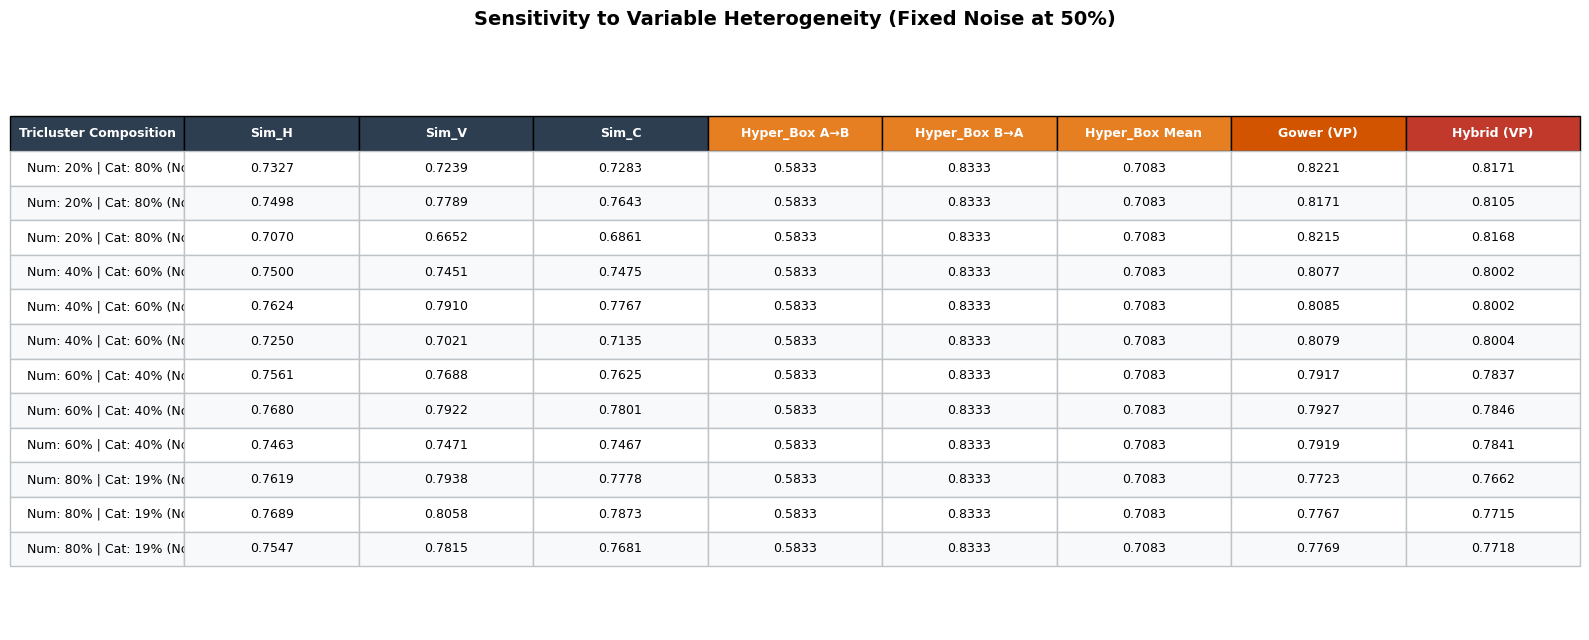


HETEROGENEITY SENSITIVITY DATA
                   Tricluster Composition  Sim_H  Sim_V  Sim_C  Hyper_Box_AB  Hyper_Box_BA  Hyper_Box_Mean  B_Gower  B_Hybr
Num: 20% | Cat: 80% (Nom: 50% / Ord: 50%) 0.7327 0.7239 0.7283        0.5833        0.8333          0.7083   0.8221  0.8171
Num: 20% | Cat: 80% (Nom: 20% / Ord: 80%) 0.7498 0.7789 0.7643        0.5833        0.8333          0.7083   0.8171  0.8105
Num: 20% | Cat: 80% (Nom: 80% / Ord: 20%) 0.7070 0.6652 0.6861        0.5833        0.8333          0.7083   0.8215  0.8168
Num: 40% | Cat: 60% (Nom: 50% / Ord: 50%) 0.7500 0.7451 0.7475        0.5833        0.8333          0.7083   0.8077  0.8002
Num: 40% | Cat: 60% (Nom: 20% / Ord: 80%) 0.7624 0.7910 0.7767        0.5833        0.8333          0.7083   0.8085  0.8002
Num: 40% | Cat: 60% (Nom: 80% / Ord: 20%) 0.7250 0.7021 0.7135        0.5833        0.8333          0.7083   0.8079  0.8004
Num: 60% | Cat: 40% (Nom: 50% / Ord: 50%) 0.7561 0.7688 0.7625        0.5833        0.8333          

In [31]:
# ==============================================================================
# 1. EXPERIMENT CONFIGURATION
# ==============================================================================
n_obs_total = 100
n_feat = 20
n_time = 10
noise_level = 50 

indices_A = list(range(0, 50))
indices_B = list(range(50, 100))
tempos = list(range(n_time))

ordered_categories = ['A', 'B', 'C', 'D', 'E']
rank_mapping = {c: i for i, c in enumerate(ordered_categories)}

ratios_main = [0.2, 0.4, 0.6, 0.8]  
ratios_cat = [(0.5, 0.5), (0.2, 0.8), (0.8, 0.2)] 

scenarios = {}

for r_num in ratios_main:
    n_num = int(n_feat * r_num)
    n_cat_total = n_feat - n_num
    
    for r_nom, r_ord in ratios_cat:
        n_nom = round(n_cat_total * r_nom)
        n_ord = n_cat_total - n_nom
        
        label = f"Num: {int(r_num*100)}% | Cat: {int((1-r_num)*100)}% (Nom: {int(r_nom*100)}% / Ord: {int(r_ord*100)}%)"
        scenarios[label] = {"num": n_num, "nom": n_nom, "ord": n_ord}


# ==============================================================================
# 2. CONTEXT TESTING FUNCTION
# ==============================================================================
def run_context_test(n_num, n_nom, n_ord):
    idx_num = list(range(n_num))
    idx_nom = list(range(n_num, n_num + n_nom))
    idx_ord = list(range(n_num + n_nom, n_num + n_nom + n_ord))
    all_f = idx_num + idx_nom + idx_ord
    
    tensor = np.full((n_feat, n_obs_total, n_time), np.nan, dtype=object)
    
    for j in all_f:
        if j in idx_num: tensor[j, :, :] = 50.0
        else: tensor[j, :, :] = 'C'
    
    cells_b = [(j, i, k) for j in all_f for i in indices_B for k in tempos]
    to_corrupt = random.sample(cells_b, int(len(cells_b) * (noise_level / 100.0)))
    
    for j, i, k in to_corrupt:
        if j in idx_num:
            tensor[j, i, k] = 50.0 + random.uniform(-12.5, 12.5)
        elif j in idx_ord:
            tensor[j, i, k] = random.choice(['A', 'B', 'D', 'E'])
        else:
            tensor[j, i, k] = random.choice(['B', 'D', 'Z'])

    m_dict = {j: 0.0 for j in idx_num}
    mx_dict = {j: 100.0 for j in idx_num}
    
    t_A, t_B = (indices_A, all_f, tempos), (indices_B, all_f, tempos)
    
    ordinal_map_dict = {j: ordered_categories for j in idx_ord}
    iqr_dict_calc, weight_dict_calc, rank_dict_calc = build_feature_stats(
        data_tensor=tensor, 
        num_idx=idx_num, 
        symb_idx=idx_nom + idx_ord, 
        ordinal_map=ordinal_map_dict
    )
    
    sh = calculate_horizontal_similarity(t_A, t_B, tensor, m_dict, mx_dict, rank_dict_calc, idx_num, idx_ord, idx_nom, lambda_param=0.5)
    sv = calculate_vertical_similarity(t_A, t_B, tensor, m_dict, mx_dict, rank_dict_calc, idx_num, idx_ord, idx_nom, lambda_param=0.5)
    sc = calculate_combined_similarity(t_A, t_B, tensor, m_dict, mx_dict, rank_dict_calc, idx_num, idx_ord, idx_nom, lambda_param=0.5, precomputed_H=sh, precomputed_V=sv)
    
    sl_gower = similarity_virtual_pattern_gower(t_A, t_B, tensor, idx_num, idx_nom + idx_ord, iqr_dict_calc, weight_dict_calc, rank_dict_calc, lambda_param=0.5)
    sl_hybr = similarity_virtual_pattern_hybrid(t_A, t_B, tensor, idx_num, idx_nom + idx_ord, iqr_dict_calc, rank_dict_calc, lambda_param=0.5)

    def calc_baseline_directional():
        sim_ab = wrapper_legacy_metric(t_A, t_B, tensor, similarity_baseline_boundary, idx_num, idx_nom + idx_ord, rank_dict_calc, lambda_param=0.5, direction="A→B")
        sim_ba = wrapper_legacy_metric(t_A, t_B, tensor, similarity_baseline_boundary, idx_num, idx_nom + idx_ord, rank_dict_calc, lambda_param=0.5, direction="B→A")
        return sim_ab, sim_ba, (sim_ab + sim_ba) / 2.0

    lb_ab, lb_ba, lb_mean = calc_baseline_directional()
    
    return sh, sv, sc, lb_ab, lb_ba, lb_mean, sl_gower, sl_hybr


# ==============================================================================
# 3. DATA REPORTING & TABULAR RENDERING
# ==============================================================================
final_results = []

for name, conf in scenarios.items():
    print(f"Processing context: {name}...")
    sh, sv, sc, lb_ab, lb_ba, lb_mean, sl_gower, sl_hybr = run_context_test(conf['num'], conf['nom'], conf['ord'])
    final_results.append({
        "Tricluster Composition": name,
        "Sim_H": sh, "Sim_V": sv, "Sim_C": sc,
        "Hyper_Box_AB": lb_ab, "Hyper_Box_BA": lb_ba, "Hyper_Box_Mean": lb_mean,
        "B_Gower": sl_gower, "B_Hybr": sl_hybr
    })

df_context = pd.DataFrame(final_results)

df_tabela = df_context.copy()
for col in df_tabela.columns:
    if col != "Tricluster Composition":
        df_tabela[col] = df_tabela[col].apply(lambda x: f"{x:.4f}")

headers = [
    "Tricluster Composition", "Sim_H", "Sim_V", "Sim_C", 
    "Hyper_Box A→B", "Hyper_Box B→A", "Hyper_Box Mean",
    "Gower (VP)", "Hybrid (VP)"
]

fig_tbl, ax_tbl = plt.subplots(figsize=(16, 6.5)) 
ax_tbl.axis('off')
ax_tbl.axis('tight')

tabela = ax_tbl.table(
    cellText=df_tabela.values,
    colLabels=headers,
    cellLoc='center',
    loc='center',
    colColours=["#2C3E50"] * len(headers)
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.0, 1.8)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        if 4 <= col <= 6: cell.set_facecolor("#E67E22")
        elif col == 7: cell.set_facecolor("#D35400")
        elif col == 8: cell.set_facecolor("#C0392B")
    else:
        if col == 0:
            cell.set_text_props(ha='left')
            cell._text.set_position((0.05, 0.5)) 
            
        if row % 2 == 0:
            cell.set_facecolor('#F8F9FA')
        cell.set_edgecolor('#BDC3C7')

plt.title("Sensitivity to Variable Heterogeneity (Fixed Noise at 50%)", fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()

OUTPUT_DIR = Path("./heterogeneity_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / "heterogeneity_sensitivity_table.png" 

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\nTable successfully exported to: {OUTPUT_PATH.absolute()}")
plt.show()

print("\n" + "="*120)
print("HETEROGENEITY SENSITIVITY DATA")
print("="*120)
print(df_context.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))
print("="*120)

## Part 6: Structural Overlap Sensitivity Test

This stress test isolates the **Structural Component** of the similarity calculation. 
To ensure that value-based variations do not interfere with the results, the entire global tensor is populated with identical values. The candidate tricluster ($T_B$) is geometrically shifted away from the reference template ($T_A$) in incremental steps of 20%.

Four overlap scenarios are evaluated:
1. Shifting only the Contexts/Time dimension ($K$).
2. Shifting only the Features dimension ($J$).
3. Shifting only the Observations dimension ($I$).
4. Parallel shifting across all three dimensions simultaneously.

In [34]:
# ==============================================================================
# 1. GLOBAL SUPPORT SPACE CONFIGURATION
# ==============================================================================
n_obs_tric = 50
n_feat_tric = 20  
n_time_tric = 10

n_obs_global = 100
n_feat_global = 40
n_time_global = 20

global_num_idx = list(range(0, 10)) + list(range(20, 30))
global_nom_idx = list(range(10, 20)) + list(range(30, 40))

# Constant tensor (Identical values isolate structural impact)
tensor_structural = np.full((n_feat_global, n_obs_global, n_time_global), np.nan, dtype=object)
for j in range(n_feat_global):
    if j in global_num_idx:
        tensor_structural[j, :, :] = 50.0
    else:
        tensor_structural[j, :, :] = 'C'

obs_A = list(range(n_obs_tric))
feat_A = list(range(n_feat_tric))
time_A = list(range(n_time_tric))
tric_A = (obs_A, feat_A, time_A)

min_dict = {j: 0.0 for j in global_num_idx}
max_dict = {j: 100.0 for j in global_num_idx}
rank_dict = {}

steps = [20, 40, 60, 80, 100]
results_exp = []

def get_indices_B(p_i, p_j, p_k):
    o_i = round(n_obs_tric * (p_i / 100.0))
    obs_B = list(range(0, o_i)) + list(range(50, 50 + (n_obs_tric - o_i)))
    
    o_num = round(10 * (p_j / 100.0))
    o_nom = round(10 * (p_j / 100.0))
    feat_B_num = list(range(0, o_num)) + list(range(20, 20 + (10 - o_num)))
    feat_B_nom = list(range(10, 10 + o_nom)) + list(range(30, 30 + (10 - o_nom)))
    feat_B = sorted(feat_B_num + feat_B_nom)
    
    o_k = round(n_time_tric * (p_k / 100.0))
    time_B = list(range(0, o_k)) + list(range(10, 10 + (n_time_tric - o_k)))
    
    return (obs_B, feat_B, time_B)

# ==============================================================================
# 2. STATE INSPECTION UTILITY
# ==============================================================================
def print_tricluster_state(scenario_name, p_step, t_A, t_B, tensor):
    I_A, J_A, K_A = t_A
    I_B, J_B, K_B = t_B
    
    J_AB = sorted(list(set(J_A).intersection(set(J_B))))
    K_AB = sorted(list(set(K_A).intersection(set(K_B))))
    I_AB = sorted(list(set(I_A).intersection(set(I_B))))
    
    def format_list(lst):
        if len(lst) > 6:
            return f"[{lst[0]}, {lst[1]}, {lst[2]}, ..., {lst[-3]}, {lst[-2]}, {lst[-1]}]"
        return str(lst)
    
    print(f"\n🔍 ANALYZING: {scenario_name} | Target Overlap: {p_step}%")
    print("-" * 75)
    print(f"  [ STRUCTURE ]")
    print(f"  A (Ref)  -> Obs: {len(I_A):02d} {format_list(I_A)} | Feat: {len(J_A):02d} {format_list(J_A)} | Time: {len(K_A):02d} {format_list(K_A)}")
    print(f"  B (Cand) -> Obs: {len(I_B):02d} {format_list(I_B)} | Feat: {len(J_B):02d} {format_list(J_B)} | Time: {len(K_B):02d} {format_list(K_B)}")
    
    print(f"\n  [ ACTUAL INTERSECTION ]")
    print(f"  Shared Elements: {len(I_AB)} Observations, {len(J_AB)} Features, {len(K_AB)} Contexts.")
    
    if K_AB and J_AB:
        t_sample = K_AB[0]
        f_sample = J_AB[0]
        f_type = "Numeric" if f_sample in global_num_idx else "Nominal"
        
        print(f"\n  [ DATA SAMPLE (Time t={t_sample}, Shared Feature F={f_sample} - {f_type}) ]")
        vals_A = [tensor[f_sample, a, t_sample] for a in I_A[:5]]
        vals_B = [tensor[f_sample, b, t_sample] for b in I_B[:5]]
        
        print(f"  Top 5 Reference Observations: {vals_A}")
        print(f"  Top 5 Candidate Observations: {vals_B}")
    else:
        print("\n  [ DATA SAMPLE ]\n  ⚠️ No shared features or contexts available for sampling.")
    print("-" * 75)

# ==============================================================================
# 3. OVERLAP EXPERIMENTS EXECUTION
# ==============================================================================
def run_overlap_scenario(scenario_name, p_i, p_j, p_k, p_step, verbose=True):
    tric_B = get_indices_B(p_i, p_j, p_k)
    
    if verbose:
        print_tricluster_state(scenario_name, p_step, tric_A, tric_B, tensor_structural)
    
    iqr_calc, weight_calc, rank_calc = build_feature_stats(tensor_structural, global_num_idx, global_nom_idx)
    
    sh = calculate_horizontal_similarity(tric_A, tric_B, tensor_structural, min_dict, max_dict, rank_calc, global_num_idx, [], global_nom_idx, lambda_param=0.5)
    sv = calculate_vertical_similarity(tric_A, tric_B, tensor_structural, min_dict, max_dict, rank_calc, global_num_idx, [], global_nom_idx, lambda_param=0.5)
    sc = calculate_combined_similarity(tric_A, tric_B, tensor_structural, min_dict, max_dict, rank_calc, global_num_idx, [], global_nom_idx, lambda_param=0.5, precomputed_H=sh, precomputed_V=sv)
    
    sg = similarity_virtual_pattern_gower(tric_A, tric_B, tensor_structural, global_num_idx, global_nom_idx, iqr_calc, weight_calc, rank_dict=rank_calc, lambda_param=0.5)
    sy = similarity_virtual_pattern_hybrid(tric_A, tric_B, tensor_structural, global_num_idx, global_nom_idx, iqr_calc, rank_dict=rank_calc, lambda_param=0.5)
    
    sb_ab = wrapper_legacy_metric(tric_A, tric_B, tensor_structural, similarity_baseline_boundary, global_num_idx, global_nom_idx, rank_calc, lambda_param=0.5, direction="A→B")
    sb_ba = wrapper_legacy_metric(tric_A, tric_B, tensor_structural, similarity_baseline_boundary, global_num_idx, global_nom_idx, rank_calc, lambda_param=0.5, direction="B→A")
    sb_mean = (sb_ab + sb_ba) / 2.0
    
    results_exp.append({
        "Experiment": scenario_name, 
        "Overlap (%)": p_step, 
        "Sim_H": sh, "Sim_V": sv, "Sim_C": sc, 
        "B_Hyper_Box (Mean)": sb_mean, "B_Gower (VP)": sg, "B_Hybr (VP)": sy
    })

VERBOSE_MODE = False

for p in steps: run_overlap_scenario("1. Varying Time Overlap (K)", 100, 100, p, p, verbose=VERBOSE_MODE)
for p in steps: run_overlap_scenario("2. Varying Feature Overlap (J)", 100, p, 100, p, verbose=VERBOSE_MODE)
for p in steps: run_overlap_scenario("3. Varying Observation Overlap (I)", p, 100, 100, p, verbose=VERBOSE_MODE)
for p in steps: run_overlap_scenario("4. Parallel Overlap (I, J, K)", p, p, p, p, verbose=VERBOSE_MODE)

df_results = pd.DataFrame(results_exp)

print("\n" + "="*100)
print("STRUCTURAL STRESS TEST: 4 OVERLAP EXPERIMENTS")
print("="*100)

columns_to_show = ["Overlap (%)", "Sim_H", "Sim_V", "Sim_C", "B_Hyper_Box (Mean)", "B_Gower (VP)", "B_Hybr (VP)"]

for exp_name in df_results["Experiment"].unique():
    print(f"\n>>> {exp_name} <<<")
    print("-" * 85)
    df_sub = df_results[df_results["Experiment"] == exp_name][columns_to_show]
    print(df_sub.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))
    print("-" * 85)

C:\Users\ruica\thesis\code\TriHSPAM-main\src\visualize_patterns.py:26: RuntimeWarning: Mean of empty slice
  vals[i] = round(np.nanmean(converted_column),2)
C:\Users\ruica\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,



STRUCTURAL STRESS TEST: 4 OVERLAP EXPERIMENTS

>>> 1. Varying Time Overlap (K) <<<
-------------------------------------------------------------------------------------
 Overlap (%)  Sim_H  Sim_V  Sim_C  B_Hyper_Box (Mean)  B_Gower (VP)  B_Hybr (VP)
          20 0.8519 0.8519 0.8519              0.8519        0.8519       0.8519
          40 0.8750 0.8750 0.8750              0.8750        0.8750       0.8750
          60 0.9048 0.9048 0.9048              0.9048        0.9048       0.9048
          80 0.9444 0.9444 0.9444              0.9444        0.9444       0.9444
         100 1.0000 1.0000 1.0000              1.0000        1.0000       1.0000
-------------------------------------------------------------------------------------

>>> 2. Varying Feature Overlap (J) <<<
-------------------------------------------------------------------------------------
 Overlap (%)  Sim_H  Sim_V  Sim_C  B_Hyper_Box (Mean)  B_Gower (VP)  B_Hybr (VP)
          20 0.8519 0.8519 0.8519              0.85

## Part 7: Runtime and Scalability Analysis (Computational Profiling)

This section evaluates the computational efficiency and scalability of the proposed symmetric metrics compared to the baseline Virtual Pattern and Hyper-box approaches.

**Profiling Strategy:**
To measure the true algorithmic overhead and prevent any "early-exit" optimizations, the dynamic benchmark generator forces a 100% structural overlap between the reference and candidate triclusters. This guarantees that all internal nested loops and mathematical calculations are fully executed.

The stress test comprises four independent scaling experiments:
1. **Varying Contexts ($K$):** Scaling the temporal dimension.
2. **Varying Features ($J$):** Scaling the variable dimension (50% numerical, 50% nominal).
3. **Varying Observations ($I$):** Scaling the patient/record dimension.
4. **Parallel Scaling:** Exponentially scaling $I$, $J$, and $K$ simultaneously.

Execution times are recorded in seconds and visualized using an inverted-axis 2x2 grid with a logarithmic time scale to clearly contrast linear versus exponential growth trajectories.

--- Starting Full Computational Profiling (6 Metrics) ---


C:\Users\ruica\thesis\code\TriHSPAM-main\src\visualize_patterns.py:26: RuntimeWarning: Mean of empty slice
  vals[i] = round(np.nanmean(converted_column),2)
C:\Users\ruica\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Success: Experiment 1 finished.
Success: Experiment 2 finished.
Success: Experiment 3 finished.
Success: Experiment 4 finished.

COMPUTATIONAL SCALABILITY STRESS TEST: EXECUTION TIME (SECONDS)

>>> 1. Varying Time (K) <<<
-----------------------------------------------------------------------------------------------
Size     Sim_H    Sim_V     Sim_C  B_Hyper_Box  B_Gower   B_Hybr
   5  0.950245 0.279311  1.243626     0.041385 0.043516 0.041945
  10  1.780792 0.544217  2.320457     0.058472 0.078725 0.079251
  20  3.600238 1.136886  4.636216     0.107623 0.160966 0.162672
  50  8.777629 2.902766 11.967790     0.243574 0.409045 0.402175
 100 17.803709 5.558949 23.135096     0.521910 0.776084 0.789707
-----------------------------------------------------------------------------------------------

>>> 2. Varying Features (J) <<<
-----------------------------------------------------------------------------------------------
Size    Sim_H    Sim_V     Sim_C  B_Hyper_Box  B_Gower   B_Hybr
   

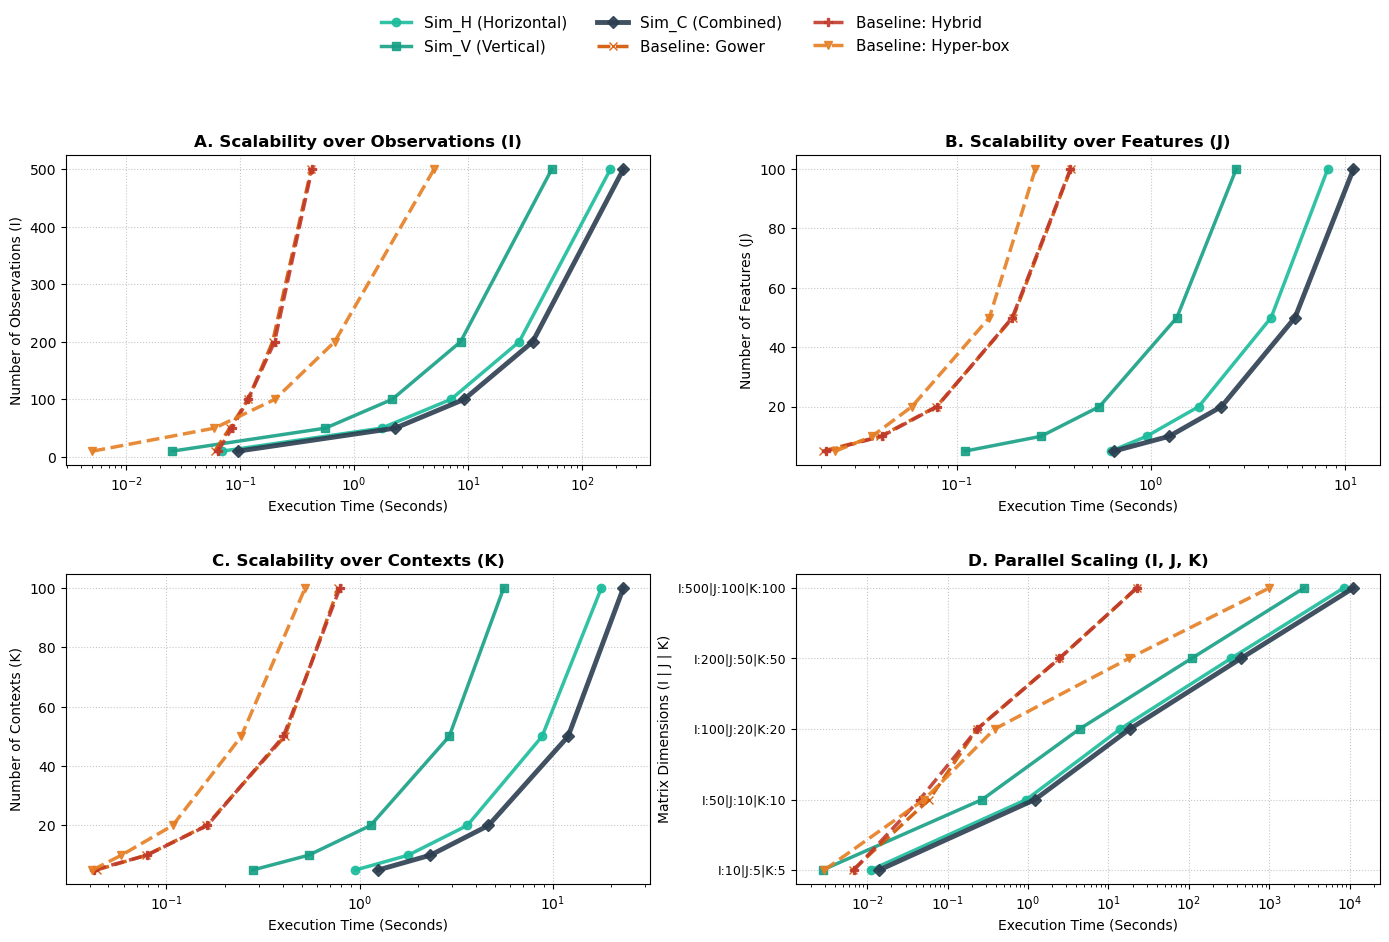

In [38]:
# ==============================================================================
# 1. AUXILIARY FUNCTION: DYNAMIC BENCHMARK SCENARIO GENERATOR
# ==============================================================================
def setup_benchmark_tensor(p_i, p_j, p_k):
    """
    Generates a tensor and two triclusters with exact dimensions for profiling.
    Ensures 100% overlap in J and K to force execution of all internal loops
    and simulate a worst-case computational scenario.
    """
    n_obs_total = 2 * p_i
    n_num = p_j // 2
    n_nom = p_j - n_num
    
    idx_num = list(range(0, n_num))
    idx_nom = list(range(n_num, p_j))
    all_f = idx_num + idx_nom
    
    tensor = np.full((p_j, n_obs_total, p_k), np.nan, dtype=object)
    for j in all_f:
        if j in idx_num:
            tensor[j, :, :] = 50.0
        else:
            tensor[j, :, :] = 'C'
            
    indices_B_global = list(range(p_i, 2 * p_i))
    tempos_global = list(range(p_k))
    cells_b = [(j, i, k) for j in all_f for i in indices_B_global for k in tempos_global]
    to_corrupt = random.sample(cells_b, int(len(cells_b) * 0.5))
    
    for j, i, k in to_corrupt:
        if j in idx_num:
            tensor[j, i, k] = 50.0 + random.uniform(-12.5, 12.5)
        else:
            tensor[j, i, k] = random.choice(['B', 'D', 'Z'])
            
    obs_A = list(range(0, p_i))
    obs_B = list(range(p_i, 2 * p_i))
    
    tric_A = (obs_A, all_f, tempos_global)
    tric_B = (obs_B, all_f, tempos_global)
    
    min_dict = {j: 0.0 for j in idx_num}
    max_dict = {j: 100.0 for j in idx_num}
    rank_dict = {}
    
    return tric_A, tric_B, tensor, min_dict, max_dict, rank_dict, idx_num, idx_nom

# ==============================================================================
# 2. PERFORMANCE EXPERIMENTS EXECUTION (ALL METRICS)
# ==============================================================================
time_results = []

print("--- Starting Full Computational Profiling (6 Metrics) ---")

def measure_all_metrics(tA, tB, tens, mn, mx, rk, i_num, i_nom):
    # 1. Proposed Symmetric Horizontal
    start = time.perf_counter()
    _ = calculate_horizontal_similarity(tA, tB, tens, mn, mx, rk, i_num, [], i_nom, lambda_param=0.5)
    t_h = time.perf_counter() - start
    
    # 2. Proposed Symmetric Vertical
    start = time.perf_counter()
    _ = calculate_vertical_similarity(tA, tB, tens, mn, mx, rk, i_num, [], i_nom, lambda_param=0.5)
    t_v = time.perf_counter() - start
    
    # 3. Proposed Symmetric Combined
    start = time.perf_counter()
    _ = calculate_combined_similarity(tA, tB, tens, mn, mx, rk, i_num, [], i_nom, lambda_param=0.5)
    t_c = time.perf_counter() - start
    
    # 4. Baseline Hyper-box (Requires computing both directions for the mean)
    start = time.perf_counter()
    _ = wrapper_legacy_metric(tA, tB, tens, similarity_baseline_boundary, i_num, i_nom, rk, lambda_param=0.5, direction="A→B")
    _ = wrapper_legacy_metric(tA, tB, tens, similarity_baseline_boundary, i_num, i_nom, rk, lambda_param=0.5, direction="B→A")
    t_base = time.perf_counter() - start
    
    # Pre-compute stats required for Gower and Hybrid Virtual Patterns
    start = time.perf_counter()
    iqr_calc, weight_calc, rank_calc = build_feature_stats(tens, i_num, i_nom)
    t_stats = time.perf_counter() - start
    
    # 5. Baseline Gower (Virtual Pattern approach)
    start = time.perf_counter()
    _ = similarity_virtual_pattern_gower(tA, tB, tens, i_num, i_nom, iqr_calc, weight_calc, rank_dict=rk, lambda_param=0.5)
    t_gower = t_stats + (time.perf_counter() - start)
    
    # 6. Baseline Hybrid (Virtual Pattern approach)
    start = time.perf_counter()
    _ = similarity_virtual_pattern_hybrid(tA, tB, tens, i_num, i_nom, iqr_calc, rank_dict=rk, lambda_param=0.5)
    t_hybr = t_stats + (time.perf_counter() - start)
    
    return t_h, t_v, t_c, t_base, t_gower, t_hybr


# --- Experiment 1: Varying Contexts/Time (K) ---
steps_k = [5, 10, 20, 50, 100]
for k in steps_k:
    tA, tB, tens, mn, mx, rk, i_num, i_nom = setup_benchmark_tensor(50, 20, k)
    th, tv, tc, tbase, tgower, thybr = measure_all_metrics(tA, tB, tens, mn, mx, rk, i_num, i_nom)
    time_results.append({"Experiment": "1. Varying Time (K)", "Size": k, "Sim_H": th, "Sim_V": tv, "Sim_C": tc, "B_Hyper_Box": tbase, "B_Gower": tgower, "B_Hybr": thybr})
print("Success: Experiment 1 finished.")

# --- Experiment 2: Varying Features (J) ---
steps_j = [5, 10, 20, 50, 100]
for j in steps_j:
    tA, tB, tens, mn, mx, rk, i_num, i_nom = setup_benchmark_tensor(50, j, 10)
    th, tv, tc, tbase, tgower, thybr = measure_all_metrics(tA, tB, tens, mn, mx, rk, i_num, i_nom)
    time_results.append({"Experiment": "2. Varying Features (J)", "Size": j, "Sim_H": th, "Sim_V": tv, "Sim_C": tc, "B_Hyper_Box": tbase, "B_Gower": tgower, "B_Hybr": thybr})
print("Success: Experiment 2 finished.")

# --- Experiment 3: Varying Observations (I) ---
steps_i = [10, 50, 100, 200, 500]
for i in steps_i:
    tA, tB, tens, mn, mx, rk, i_num, i_nom = setup_benchmark_tensor(i, 20, 10)
    th, tv, tc, tbase, tgower, thybr = measure_all_metrics(tA, tB, tens, mn, mx, rk, i_num, i_nom)
    time_results.append({"Experiment": "3. Varying Observations (I)", "Size": i, "Sim_H": th, "Sim_V": tv, "Sim_C": tc, "B_Hyper_Box": tbase, "B_Gower": tgower, "B_Hybr": thybr})
print("Success: Experiment 3 finished.")

# --- Experiment 4: Varying All Dimensions (I, J, K) Parallelly ---
parallel_steps = [
    {"i": 10,  "j": 5,   "k": 5},
    {"i": 50,  "j": 10,  "k": 10},
    {"i": 100, "j": 20,  "k": 20},
    {"i": 200, "j": 50,  "k": 50},
    {"i": 500, "j": 100, "k": 100}
]
for step in parallel_steps:
    tA, tB, tens, mn, mx, rk, i_num, i_nom = setup_benchmark_tensor(step["i"], step["j"], step["k"])
    th, tv, tc, tbase, tgower, thybr = measure_all_metrics(tA, tB, tens, mn, mx, rk, i_num, i_nom)
    label = f"I:{step['i']}|J:{step['j']}|K:{step['k']}"
    time_results.append({"Experiment": "4. Parallel Scaling", "Size": label, "Sim_H": th, "Sim_V": tv, "Sim_C": tc, "B_Hyper_Box": tbase, "B_Gower": tgower, "B_Hybr": thybr})
print("Success: Experiment 4 finished.")

df_time = pd.DataFrame(time_results)

# ==============================================================================
# 3. FULL EXECUTION REPORT
# ==============================================================================
print("\n" + "="*110)
print("COMPUTATIONAL SCALABILITY STRESS TEST: EXECUTION TIME (SECONDS)")
print("="*110)

for exp_name in df_time["Experiment"].unique():
    print(f"\n>>> {exp_name} <<<")
    print("-" * 95)
    df_sub = df_time[df_time["Experiment"] == exp_name][["Size", "Sim_H", "Sim_V", "Sim_C", "B_Hyper_Box", "B_Gower", "B_Hybr"]]
    print(df_sub.to_string(index=False, float_format=lambda x: "{:.6f}".format(x)))
    print("-" * 95)


# ==============================================================================
# 4. GRAPHICAL RENDERING (INVERTED AXES 2x2 GRID)
# ==============================================================================
OUTPUT_DIR = Path("./scalability_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_PNG = OUTPUT_DIR / "computational_test.png"
OUTPUT_PATH_PDF = OUTPUT_DIR / "computational_test.pdf"

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten() 

style_map = {
    "Sim_H":   {"label": "Sim_H (Horizontal)", "color": "#1ABC9C", "marker": "o", "ls": "-", "lw": 2.5},
    "Sim_V":   {"label": "Sim_V (Vertical)",   "color": "#16A085", "marker": "s", "ls": "-", "lw": 2.5},
    "Sim_C":   {"label": "Sim_C (Combined)",   "color": "#2C3E50", "marker": "D", "ls": "-", "lw": 3.5},
    "B_Gower": {"label": "Baseline: Gower",    "color": "#D35400", "marker": "x", "ls": "--", "lw": 2.5},
    "B_Hybr":  {"label": "Baseline: Hybrid",   "color": "#C0392B", "marker": "P", "ls": "--", "lw": 2.5},
    "B_Hyper_Box":  {"label": "Baseline: Hyper-box","color": "#E67E22", "marker": "v", "ls": "--", "lw": 2.5}
}

plot_configs = [
    {"exp": "3. Varying Observations (I)", "title": "A. Scalability over Observations (I)", "ylabel": "Number of Observations (I)"},
    {"exp": "2. Varying Features (J)",     "title": "B. Scalability over Features (J)",     "ylabel": "Number of Features (J)"},
    {"exp": "1. Varying Time (K)",         "title": "C. Scalability over Contexts (K)",     "ylabel": "Number of Contexts (K)"},
    {"exp": "4. Parallel Scaling",         "title": "D. Parallel Scaling (I, J, K)",        "ylabel": "Matrix Dimensions (I | J | K)"}
]

for i, config in enumerate(plot_configs):
    ax = axes[i]
    df_sub = df_time[df_time["Experiment"] == config["exp"]].copy()
    
    y_data = df_sub["Size"]
    
    # Handle string labels for Parallel Scaling
    is_categorical = (i == 3)
    y_plot = range(len(y_data)) if is_categorical else y_data
    
    # Plotting: Execution Time on X-axis, Size on Y-axis
    for col, style in style_map.items():
        ax.plot(df_sub[col], y_plot, 
                label=style["label"], color=style["color"], 
                marker=style["marker"], linestyle=style["ls"], linewidth=style["lw"], 
                markersize=6, alpha=0.9)
    
    ax.set_title(config["title"], fontweight='bold', fontsize=12)
    ax.set_ylabel(config["ylabel"], fontsize=10)
    ax.set_xlabel("Execution Time (Seconds)", fontsize=10)
        
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # Apply logarithmic scale to Time (X-axis)
    ax.set_xscale('log') 
    
    if is_categorical:
        ax.set_yticks(range(len(y_data)))
        ax.set_yticklabels(y_data, fontsize=9)

# Global Legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=11, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25)

# Export Phase
plt.savefig(OUTPUT_PATH_PNG, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(OUTPUT_PATH_PDF, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\nProfiling Grid Exported successfully to:")
print(f" - {OUTPUT_PATH_PNG.absolute()}")

plt.show()